# BBL Cricket — Extended Analysis Notebook
**Usama Asif — a1917716**  
*DS Project B — University of Adelaide*

This notebook extends the home advantage analysis with three new investigations:
1. **Toss hypothesis tests** — does winning the toss significantly affect match outcome?
2. **First innings prediction** — can we predict the winner from first innings runs and wickets?
3. **Combined model** — does home advantage still matter after accounting for first innings score?

All data is loaded from the cleaned CSV files produced in the main notebook.


In [1]:
# Import core libraries: pandas, numpy, matplotlib, statsmodels, scipy.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Libraries loaded.")


Libraries loaded.


In [2]:
# Load cleaned match and ball-by-ball CSVs from the pipeline output.
DATA_DIR = "/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/"

matches = pd.read_csv(DATA_DIR + "cleaned_match_data.csv")
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

# Remove non-decisive matches
invalid = ['no result', 'tie', 'bowl off', 'bowl-off', 'abandoned']
matches = matches[
    (~matches['result'].str.lower().isin(invalid)) &
    (matches['winner'].notna())
].copy().reset_index(drop=True)

print(f"Decisive matches loaded: {len(matches)}")
print(f"Date range: {matches['date'].min().date()} to {matches['date'].max().date()}")
print(f"\nColumns: {list(matches.columns)}")


Decisive matches loaded: 604
Date range: 2011-12-16 to 2025-01-27

Columns: ['match_id', 'date', 'team1', 'team2', 'winner', 'result', 'winner_by_runs', 'winner_by_wickets', 'venue', 'toss_winner', 'toss_decision', 'home_team']


In [3]:
# Sanity check: print sample rows and key column names.
print("Sample of loaded data:")
print(matches[['match_id', 'date', 'team1', 'team2', 'home_team',
               'toss_winner', 'toss_decision', 'winner']].head(8).to_string(index=False))

print(f"\nTotal matches: {len(matches)}")
print(f"Matches with known home team: {matches['home_team'].notna().sum()}")
print(f"Matches at neutral venues: {matches['home_team'].isna().sum()}")


Sample of loaded data:
 match_id       date               team1               team2           home_team         toss_winner toss_decision            winner
   524915 2011-12-16       Sydney Sixers       Brisbane Heat       Sydney Sixers       Brisbane Heat           bat     Sydney Sixers
   524916 2011-12-17     Melbourne Stars      Sydney Thunder     Melbourne Stars      Sydney Thunder         field    Sydney Thunder
   524917 2011-12-18   Adelaide Strikers Melbourne Renegades   Adelaide Strikers Melbourne Renegades         field Adelaide Strikers
   524918 2011-12-18     Perth Scorchers   Hobart Hurricanes     Perth Scorchers   Hobart Hurricanes           bat Hobart Hurricanes
   524919 2011-12-20       Brisbane Heat     Melbourne Stars       Brisbane Heat     Melbourne Stars           bat   Melbourne Stars
   524920 2011-12-21   Hobart Hurricanes       Sydney Sixers   Hobart Hurricanes   Hobart Hurricanes           bat Hobart Hurricanes
   524921 2011-12-22 Melbourne Renegades     P

---
## Section 1: Toss Hypothesis Tests

We test three questions using a **two-sided binomial test**:

1. **Toss advantage** — Does winning the toss help you win the match?  
   - p = proportion of matches where the toss winner also won the match  
   - H₀: p = 0.5 (no advantage)

2. **Batting first advantage** — Does batting first help you win?  
   - q = proportion of matches where the team batting first won  
   - H₀: q = 0.5 (no advantage)

3. **Toss + bat advantage** — If you win the toss and choose to bat, does that help?  
   - r = proportion of toss-winners who chose to bat AND won  
   - H₀: r = 0.5 (no advantage)

A p-value < 0.05 means we reject H₀ and conclude there is a statistically significant effect.


### Step 1 — Prepare the Data

In [4]:
# Filter to matches with complete toss information.
toss_df = matches.dropna(subset=['toss_winner', 'toss_decision', 'winner']).copy()

# Did the toss winner also win the match?
toss_df['toss_winner_won'] = (toss_df['toss_winner'] == toss_df['winner']).astype(int)

# Who batted first?
# If toss winner chose to bat → toss winner batted first
# If toss winner chose to field → the other team batted first
toss_df['batting_first'] = toss_df.apply(
    lambda row: row['toss_winner'] if row['toss_decision'] == 'bat'
    else ([t for t in [row['team1'], row['team2']] if t != row['toss_winner']][0]),
    axis=1
)
toss_df['batting_first_won'] = (toss_df['batting_first'] == toss_df['winner']).astype(int)

# Among toss winners who chose to bat — did they win?
bat_after_toss = toss_df[toss_df['toss_decision'] == 'bat'].copy()
bat_after_toss['won'] = (bat_after_toss['toss_winner'] == bat_after_toss['winner']).astype(int)

print(f"Total matches with toss info : {len(toss_df)}")
print(f"Toss winner chose to bat     : {len(toss_df[toss_df['toss_decision'] == 'bat'])}")
print(f"Toss winner chose to field   : {len(toss_df[toss_df['toss_decision'] == 'field'])}")
print(f"\nSample:")
print(toss_df[['match_id','toss_winner','toss_decision','batting_first','winner',
               'toss_winner_won','batting_first_won']].head(6).to_string(index=False))


Total matches with toss info : 604
Toss winner chose to bat     : 247
Toss winner chose to field   : 357

Sample:
 match_id         toss_winner toss_decision     batting_first            winner  toss_winner_won  batting_first_won
   524915       Brisbane Heat           bat     Brisbane Heat     Sydney Sixers                0                  0
   524916      Sydney Thunder         field   Melbourne Stars    Sydney Thunder                1                  0
   524917 Melbourne Renegades         field Adelaide Strikers Adelaide Strikers                0                  1
   524918   Hobart Hurricanes           bat Hobart Hurricanes Hobart Hurricanes                1                  1
   524919     Melbourne Stars           bat   Melbourne Stars   Melbourne Stars                1                  1
   524920   Hobart Hurricanes           bat Hobart Hurricanes Hobart Hurricanes                1                  1


### Test 1 — Does Winning the Toss Help? (p)

In [5]:
# Binomial test: does toss winner win the match more than 50% of the time?
from scipy import stats

n_toss    = len(toss_df)
wins_toss = toss_df['toss_winner_won'].sum()
p         = wins_toss / n_toss

# Binomial test: H0: p = 0.5
result_p = stats.binomtest(wins_toss, n_toss, p=0.5, alternative='two-sided')

print("=" * 50)
print("TEST 1: Does winning the toss help?")
print("=" * 50)
print(f"  Matches analysed          : {n_toss}")
print(f"  Toss winner won           : {wins_toss}")
print(f"  p (estimated probability) : {p:.4f}")
print(f"  p-value                   : {result_p.pvalue:.4f}")
print()
if result_p.pvalue < 0.05:
    print("  CONCLUSION: Reject H0 — winning the toss gives a")
    print("  statistically significant advantage (p < 0.05).")
else:
    print("  CONCLUSION: Fail to reject H0 — no statistically")
    print("  significant advantage to winning the toss (p >= 0.05).")


TEST 1: Does winning the toss help?
  Matches analysed          : 604
  Toss winner won           : 316
  p (estimated probability) : 0.5232
  p-value                   : 0.2719

  CONCLUSION: Fail to reject H0 — no statistically
  significant advantage to winning the toss (p >= 0.05).


### Test 2 — Does Batting First Help? (q)

In [6]:
# Compute proportion of matches won by the team that batted first.
n_bat    = len(toss_df)
wins_bat = toss_df['batting_first_won'].sum()
q        = wins_bat / n_bat

result_q = stats.binomtest(wins_bat, n_bat, p=0.5, alternative='two-sided')

print("=" * 50)
print("TEST 2: Does batting first help?")
print("=" * 50)
print(f"  Matches analysed          : {n_bat}")
print(f"  Batting first team won    : {wins_bat}")
print(f"  q (estimated probability) : {q:.4f}")
print(f"  p-value                   : {result_q.pvalue:.4f}")
print()
if result_q.pvalue < 0.05:
    print("  CONCLUSION: Reject H0 — batting first gives a")
    print("  statistically significant advantage (p < 0.05).")
else:
    print("  CONCLUSION: Fail to reject H0 — no statistically")
    print("  significant advantage to batting first (p >= 0.05).")


TEST 2: Does batting first help?
  Matches analysed          : 604
  Batting first team won    : 291
  q (estimated probability) : 0.4818
  p-value                   : 0.3929

  CONCLUSION: Fail to reject H0 — no statistically
  significant advantage to batting first (p >= 0.05).


### Test 3 — Does Winning the Toss AND Choosing to Bat Help? (r)

In [7]:
# Binomial test: does winning the toss AND batting first increase win rate?
n_r    = len(bat_after_toss)
wins_r = bat_after_toss['won'].sum()
r      = wins_r / n_r if n_r > 0 else 0

result_r = stats.binomtest(wins_r, n_r, p=0.5, alternative='two-sided')

print("=" * 50)
print("TEST 3: Win toss + bat first = win match?")
print("=" * 50)
print(f"  Matches where toss winner batted : {n_r}")
print(f"  Those who also won the match     : {wins_r}")
print(f"  r (estimated probability)        : {r:.4f}")
print(f"  p-value                          : {result_r.pvalue:.4f}")
print()
if result_r.pvalue < 0.05:
    print("  CONCLUSION: Reject H0 — winning the toss and batting")
    print("  first gives a statistically significant advantage (p < 0.05).")
else:
    print("  CONCLUSION: Fail to reject H0 — no statistically significant")
    print("  advantage to winning the toss and choosing to bat (p >= 0.05).")


TEST 3: Win toss + bat first = win match?
  Matches where toss winner batted : 247
  Those who also won the match     : 125
  r (estimated probability)        : 0.5061
  p-value                          : 0.8988

  CONCLUSION: Fail to reject H0 — no statistically significant
  advantage to winning the toss and choosing to bat (p >= 0.05).


### Summary of All Three Tests

                       Test   N  Wins  Estimated Prob  p-value Significant (p<0.05)
 p — Toss winner wins match 604   316          0.5232   0.2719                   No
q — Batting first team wins 604   291          0.4818   0.3929                   No
r — Toss winner bats & wins 247   125          0.5061   0.8988                   No


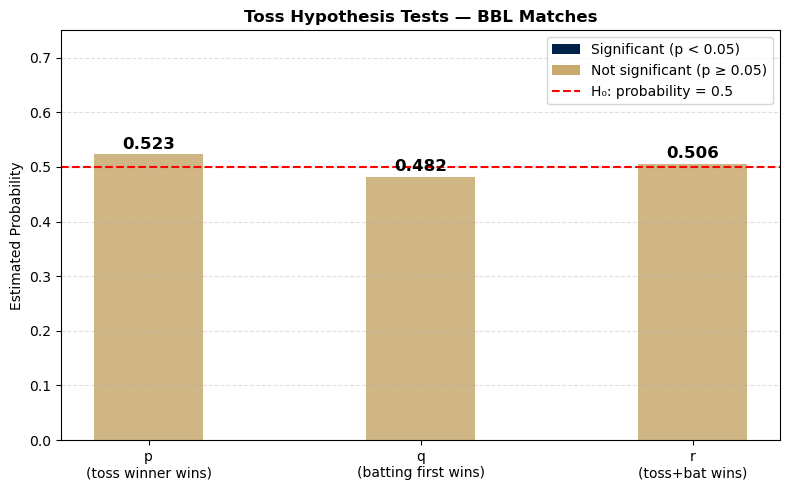

In [8]:
# Summarise all three toss tests in a table and bar chart.
import pandas as pd
import matplotlib.pyplot as plt

# Summary table
summary = pd.DataFrame({
    'Test': ['p — Toss winner wins match',
             'q — Batting first team wins',
             'r — Toss winner bats & wins'],
    'N': [n_toss, n_bat, n_r],
    'Wins': [wins_toss, wins_bat, wins_r],
    'Estimated Prob': [round(p, 4), round(q, 4), round(r, 4)],
    'p-value': [round(result_p.pvalue, 4),
                round(result_q.pvalue, 4),
                round(result_r.pvalue, 4)],
    'Significant (p<0.05)': [
        'Yes' if result_p.pvalue < 0.05 else 'No',
        'Yes' if result_q.pvalue < 0.05 else 'No',
        'Yes' if result_r.pvalue < 0.05 else 'No',
    ]
})
print(summary.to_string(index=False))

# Bar chart of estimated probabilities
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['p\n(toss winner wins)', 'q\n(batting first wins)', 'r\n(toss+bat wins)']
values = [p, q, r]
colours = ['#002147' if result_p.pvalue < 0.05 else '#C8A96E',
           '#002147' if result_q.pvalue < 0.05 else '#C8A96E',
           '#002147' if result_r.pvalue < 0.05 else '#C8A96E']

bars = ax.bar(labels, values, color=colours, alpha=0.85, width=0.4)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='H₀: probability = 0.5')
ax.set_ylim(0, 0.75)
ax.set_ylabel("Estimated Probability")
ax.set_title("Toss Hypothesis Tests — BBL Matches", fontweight='bold')
ax.legend()

# Add value labels on bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

# Colour legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#002147', label='Significant (p < 0.05)'),
                   Patch(facecolor='#C8A96E', label='Not significant (p ≥ 0.05)')]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0], loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/toss_hypothesis_tests.png", dpi=150)
plt.show()


---
## Section 2: Predicting Match Outcome from First Innings Results

Can we predict who wins just by looking at what happened in the first innings?

We build three models progressively:
1. **Model A** — predict winner from first innings runs only
2. **Model B** — add first innings wickets as a continuous variable
3. **Model C** — add first innings wickets as a categorical variable (factor)

The outcome variable is:
- `win = 1` if the team batting first won the match
- `win = 0` if the team batting second won (i.e. successfully chased)


### Step 1 — Build First Innings Dataset

In [9]:
# Aggregate ball-by-ball data to first-innings totals per match.
import pandas as pd
import numpy as np

balls = pd.read_csv("/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/cleaned_ball_by_ball_data.csv")
matches_clean = matches.copy()

# Keep only first innings deliveries
first_innings = balls[balls['innings'] == 1].copy()

# Aggregate per match — total runs and wickets in first innings
first_innings_agg = (
    first_innings.groupby('match_id')
    .agg(
        first_innings_runs    = ('runs_total', 'sum'),
        first_innings_wickets = ('wicket', 'sum'),
        batting_first_team    = ('team', 'first')
    )
    .reset_index()
)

# Merge with match outcomes
first_innings_agg['match_id'] = first_innings_agg['match_id'].astype(str)
matches_clean['match_id']     = matches_clean['match_id'].astype(str)

innings_df = first_innings_agg.merge(
    matches_clean[['match_id', 'winner']],
    on='match_id', how='inner'
)

# Outcome: did the team batting first win?
innings_df['win'] = (innings_df['batting_first_team'] == innings_df['winner']).astype(int)

# Wickets as categorical (0-10)
innings_df['first_innings_wickets_cat'] = innings_df['first_innings_wickets'].clip(0, 10).astype(str)

innings_df.to_csv("/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/first_innings_df.csv", index=False)

print(f"Matches with first innings data: {len(innings_df)}")
print(f"Batting first team won: {innings_df['win'].sum()} ({innings_df['win'].mean():.1%})")
print(f"\nFirst innings runs — summary:")
print(innings_df['first_innings_runs'].describe().round(2))
print(f"\nFirst innings wickets — summary:")
print(innings_df['first_innings_wickets'].describe().round(2))
print(f"\nSample:")
print(innings_df[['match_id','batting_first_team','first_innings_runs',
                   'first_innings_wickets','winner','win']].head(6).to_string(index=False))


Matches with first innings data: 604
Batting first team won: 291 (48.2%)

First innings runs — summary:
count   604.0000
mean    161.4300
std      28.3000
min      69.0000
25%     144.0000
50%     162.0000
75%     179.0000
max     273.0000
Name: first_innings_runs, dtype: float64

First innings wickets — summary:
count   604.0000
mean      6.4200
std       2.0300
min       1.0000
25%       5.0000
50%       6.0000
75%       8.0000
max      10.0000
Name: first_innings_wickets, dtype: float64

Sample:
match_id batting_first_team  first_innings_runs  first_innings_wickets            winner  win
  524915      Brisbane Heat                 139                      8     Sydney Sixers    0
  524916    Melbourne Stars                 153                      7    Sydney Thunder    0
  524917  Adelaide Strikers                 189                      5 Adelaide Strikers    1
  524918  Hobart Hurricanes                 140                     10 Hobart Hurricanes    1
  524919    Melbourne Star

### Step 2 — Visualise First Innings Runs by Outcome

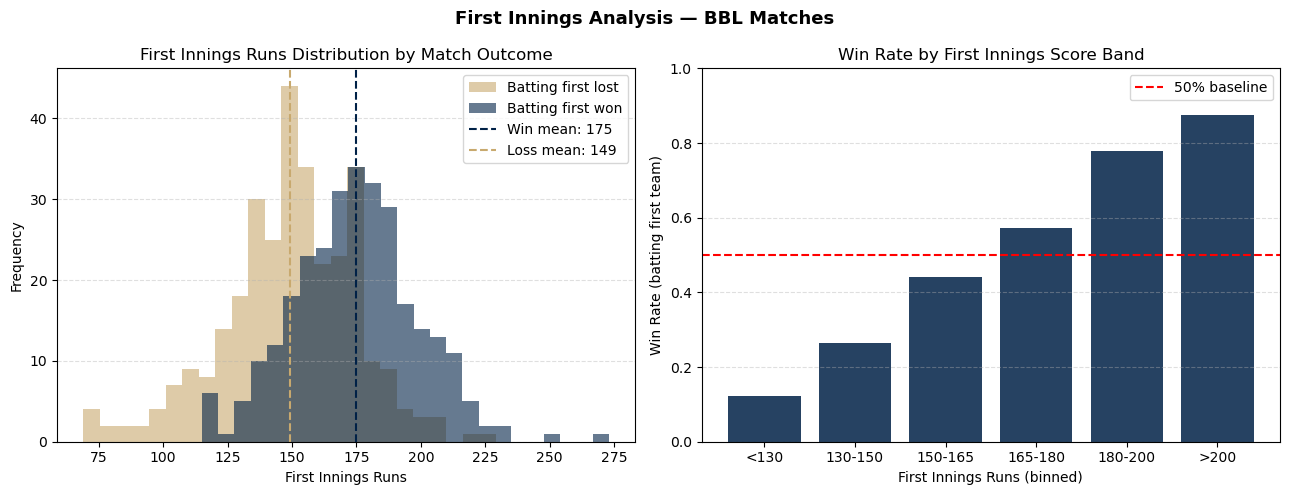

In [10]:
# Plot first-innings run distributions for wins vs losses.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Distribution of first innings runs by outcome
won  = innings_df[innings_df['win'] == 1]['first_innings_runs']
lost = innings_df[innings_df['win'] == 0]['first_innings_runs']

axes[0].hist(lost, bins=25, alpha=0.6, color='#C8A96E', label='Batting first lost')
axes[0].hist(won,  bins=25, alpha=0.6, color='#002147', label='Batting first won')
axes[0].axvline(won.mean(),  color='#002147', linestyle='--', linewidth=1.5, label=f'Win mean: {won.mean():.0f}')
axes[0].axvline(lost.mean(), color='#C8A96E', linestyle='--', linewidth=1.5, label=f'Loss mean: {lost.mean():.0f}')
axes[0].set_xlabel("First Innings Runs")
axes[0].set_ylabel("Frequency")
axes[0].set_title("First Innings Runs Distribution by Match Outcome")
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Plot 2: Win rate by first innings runs (binned)
innings_df['runs_bin'] = pd.cut(innings_df['first_innings_runs'],
                                 bins=[0,130,150,165,180,200,300],
                                 labels=['<130','130-150','150-165','165-180','180-200','>200'])
win_by_bin = innings_df.groupby('runs_bin', observed=True)['win'].mean()

axes[1].bar(win_by_bin.index, win_by_bin.values, color='#002147', alpha=0.85)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='50% baseline')
axes[1].set_xlabel("First Innings Runs (binned)")
axes[1].set_ylabel("Win Rate (batting first team)")
axes[1].set_title("Win Rate by First Innings Score Band")
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("First Innings Analysis — BBL Matches", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/first_innings_distribution.png", dpi=150)
plt.show()


### Model A — First Innings Runs Only

In [11]:
# Model A: logistic regression — win ~ first_innings_runs.
import statsmodels.formula.api as smf

model_a = smf.logit("win ~ first_innings_runs", data=innings_df).fit()
print(model_a.summary())


Optimization terminated successfully.
         Current function value: 0.573605
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                  604
Model:                          Logit   Df Residuals:                      602
Method:                           MLE   Df Model:                            1
Date:                Sun, 10 May 2026   Pseudo R-squ.:                  0.1717
Time:                        00:15:30   Log-Likelihood:                -346.46
converged:                       True   LL-Null:                       -418.26
Covariance Type:            nonrobust   LLR p-value:                 4.335e-33
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -7.0276      0.705     -9.973      0.000      -8.409      -5.647
first

### Model B — Runs + Wickets (continuous)

In [12]:
# Model B: logistic regression — win ~ first_innings_runs + wickets.
model_b = smf.logit("win ~ first_innings_runs + first_innings_wickets",
                     data=innings_df).fit()
print(model_b.summary())


Optimization terminated successfully.
         Current function value: 0.570788
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                  604
Model:                          Logit   Df Residuals:                      601
Method:                           MLE   Df Model:                            2
Date:                Sun, 10 May 2026   Pseudo R-squ.:                  0.1757
Time:                        00:15:30   Log-Likelihood:                -344.76
converged:                       True   LL-Null:                       -418.26
Covariance Type:            nonrobust   LLR p-value:                 1.195e-32
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -5.6870      0.993     -5.728      0.000      -7.633      -3.

### Model C — Runs + Wickets (categorical / factor)

In [13]:
# Model C: logistic regression — win ~ first_innings_runs + C(wickets).
model_c = smf.logit("win ~ first_innings_runs + C(first_innings_wickets_cat)",
                     data=innings_df).fit()
print(model_c.summary())


         Current function value: 0.565389
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                  604
Model:                          Logit   Df Residuals:                      593
Method:                           MLE   Df Model:                           10
Date:                Sun, 10 May 2026   Pseudo R-squ.:                  0.1835
Time:                        00:15:30   Log-Likelihood:                -341.50
converged:                      False   LL-Null:                       -418.26
Covariance Type:            nonrobust   LLR p-value:                 6.995e-28
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             11.8673   8483.478      0.001      0.999   -1.66e+04    1.

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Model Comparison — A vs B vs C

In [14]:
# Compare Models A, B, C: ROC-AUC, accuracy, log-loss.
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

def evaluate(model, df, label):
    pred = model.predict(df)
    actual = df['win'].values
    return {
        'Model': label,
        'AIC': round(model.aic, 2),
        'AUC': round(roc_auc_score(actual, pred), 4),
        'Accuracy': round(accuracy_score(actual, (pred >= 0.5).astype(int)), 4),
        'Log-Loss': round(log_loss(actual, pred), 4),
    }

comparison = pd.DataFrame([
    evaluate(model_a, innings_df, 'Model A — Runs only'),
    evaluate(model_b, innings_df, 'Model B — Runs + Wickets (continuous)'),
    evaluate(model_c, innings_df, 'Model C — Runs + Wickets (factor)'),
])

print("=== Model Comparison ===")
print(comparison.to_string(index=False))
comparison.to_csv("/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/first_innings_model_comparison.csv", index=False)


=== Model Comparison ===
                                Model      AIC    AUC  Accuracy  Log-Loss
                  Model A — Runs only 696.9200 0.7687    0.7020    0.5736
Model B — Runs + Wickets (continuous) 695.5100 0.7694    0.7003    0.5708
    Model C — Runs + Wickets (factor) 704.9900 0.7731    0.6871    0.5654


### Predicted Win Probability vs First Innings Score

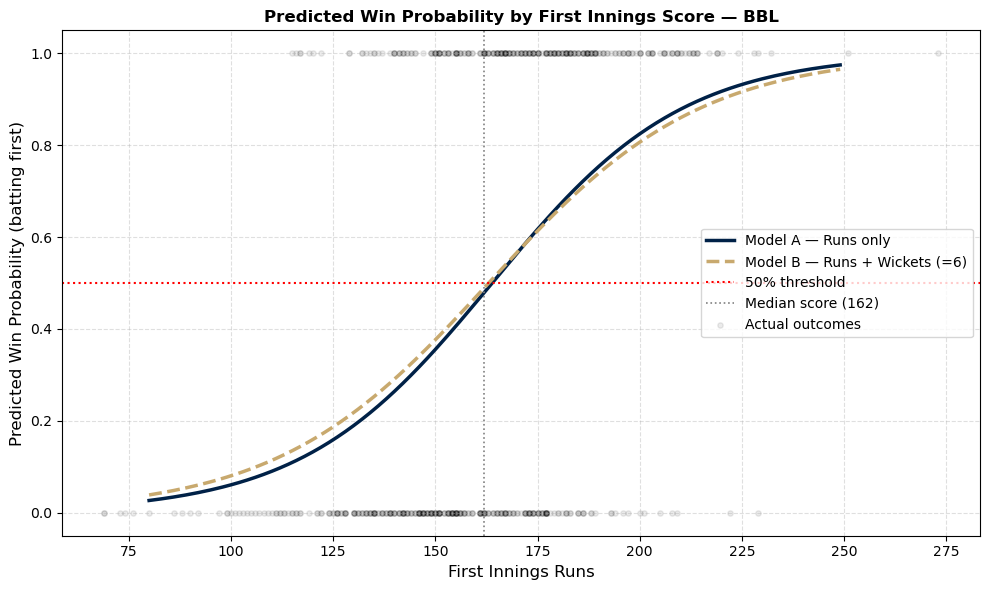

In [15]:
# Plot predicted win probability curve across first-innings score range.
import numpy as np
import matplotlib.pyplot as plt

run_range = np.arange(80, 250, 1)
pred_data = pd.DataFrame({
    'first_innings_runs': run_range,
    'first_innings_wickets': 6,  # typical
    'first_innings_wickets_cat': '6'
})

pred_a = model_a.predict(pred_data)
pred_b = model_b.predict(pred_data)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(run_range, pred_a, color='#002147', linewidth=2.5, label='Model A — Runs only')
ax.plot(run_range, pred_b, color='#C8A96E', linewidth=2.5, linestyle='--',
        label='Model B — Runs + Wickets (=6)')
ax.axhline(0.5, color='red', linestyle=':', linewidth=1.5, label='50% threshold')
ax.axvline(innings_df['first_innings_runs'].median(), color='grey',
           linestyle=':', linewidth=1.2, label=f'Median score ({innings_df["first_innings_runs"].median():.0f})')

# Scatter actual data
ax.scatter(innings_df['first_innings_runs'], innings_df['win'],
           alpha=0.08, color='black', s=15, label='Actual outcomes')

ax.set_xlabel("First Innings Runs", fontsize=12)
ax.set_ylabel("Predicted Win Probability (batting first)", fontsize=12)
ax.set_title("Predicted Win Probability by First Innings Score — BBL", fontweight='bold')
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/first_innings_prediction_curve.png", dpi=150)
plt.show()


---
## Section 3: Does Home Advantage Persist After Controlling for First Innings Score?

In Section 2 we showed that first innings runs strongly predict match outcomes (AUC ≈ 0.77).  
But home teams may systematically score more in the first innings — so is "home advantage" really just a scoring advantage in disguise?

We answer this by fitting a **combined logistic regression model** that includes both home status and first innings runs as predictors. If `is_home` remains significant after controlling for runs, home advantage is a real, independent effect.

**Models fitted:**
- **Baseline** — `win ~ is_home` (home advantage alone)
- **Runs only** — `win ~ first_innings_runs` (replicates Model A from Section 2)
- **Combined** — `win ~ is_home + first_innings_runs` (key model)
- **Full** — `win ~ is_home + first_innings_runs + first_innings_wickets` (adds wickets)


### Step 1 — Merge First Innings Data with Home Advantage Data

In [16]:
# Merge first-innings aggregates with home team indicator.
import pandas as pd
import numpy as np

BALLS_PATH   = "/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/cleaned_ball_by_ball_data.csv"
MATCHES_PATH = "/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/cleaned_match_data.csv"

balls   = pd.read_csv(BALLS_PATH)
matches = pd.read_csv(MATCHES_PATH)

# --- First innings only ---
first_inn = balls[balls['innings'] == 1].copy()

# Aggregate runs and wickets per match
# 'team' = batting team, 'wicket' = 0/1 flag, 'runs_batter' = batter runs
first_inn_agg = (
    first_inn.groupby('match_id')
    .agg(
        first_innings_runs    = ('runs_batter', 'sum'),
        first_innings_wickets = ('wicket', 'sum'),
        batting_first_team    = ('team', 'first'),
    )
    .reset_index()
)
first_inn_agg['first_innings_wickets'] = first_inn_agg['first_innings_wickets'].astype(int)

# --- Merge with match-level data ---
combined = first_inn_agg.merge(
    matches[['match_id', 'winner', 'home_team', 'venue']],
    on='match_id', how='inner'
)
combined = combined.dropna(subset=['winner'])

# win = 1 if the batting-first team won
combined['win'] = (combined['batting_first_team'] == combined['winner']).astype(int)

# is_home = 1 if the home team batted first
combined['is_home'] = (combined['batting_first_team'] == combined['home_team']).astype(int)

print(f"Combined dataset: {len(combined)} matches")
print(f"Home team batted first: {combined['is_home'].sum()} ({combined['is_home'].mean()*100:.1f}%)")
print(f"Batting-first win rate overall: {combined['win'].mean()*100:.1f}%")
print(f"\nWin rate when home team bats first: {combined[combined['is_home']==1]['win'].mean()*100:.1f}%")
print(f"Win rate when away team bats first: {combined[combined['is_home']==0]['win'].mean()*100:.1f}%")
print(f"\nMean first innings runs — home batting first: {combined[combined['is_home']==1]['first_innings_runs'].mean():.1f}")
print(f"Mean first innings runs — away batting first: {combined[combined['is_home']==0]['first_innings_runs'].mean():.1f}")

Combined dataset: 604 matches
Home team batted first: 273 (45.2%)
Batting-first win rate overall: 48.2%

Win rate when home team bats first: 51.3%
Win rate when away team bats first: 45.6%

Mean first innings runs — home batting first: 155.1
Mean first innings runs — away batting first: 152.9


### Step 2 — Fit the Four Models

In [17]:
# Fit four nested logistic models: M1(home), M2(home+score), M3(interaction), M4(mixed).
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Model 1 — Baseline: home advantage only
m1 = smf.logit("win ~ is_home", data=combined).fit(disp=False)

# Model 2 — Runs only (replicates Section 2 Model A)
m2 = smf.logit("win ~ first_innings_runs", data=combined).fit(disp=False)

# Model 3 — Combined: home + runs (KEY MODEL)
m3 = smf.logit("win ~ is_home + first_innings_runs", data=combined).fit(disp=False)

# Model 4 — Full: home + runs + wickets
m4 = smf.logit("win ~ is_home + first_innings_runs + first_innings_wickets", data=combined).fit(disp=False)

# --- Print combined model summary (the key result) ---
print("=" * 60)
print("MODEL 3 — Combined: win ~ is_home + first_innings_runs")
print("=" * 60)
print(m3.summary2().tables[1].to_string())
print(f"\nPseudo R²: {m3.prsquared:.4f}")
print(f"AIC: {m3.aic:.2f}")


MODEL 3 — Combined: win ~ is_home + first_innings_runs
                     Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
Intercept          -6.8326    0.6870 -9.9458 0.0000 -8.1791 -5.4862
is_home             0.2094    0.1846  1.1346 0.2565 -0.1523  0.5711
first_innings_runs  0.0431    0.0043  9.9240 0.0000  0.0346  0.0516

Pseudo R²: 0.1705
AIC: 699.87


### Step 3 — Compare All Four Models

In [18]:
# Compare all four models: ROC-AUC, accuracy, log-loss.
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

def evaluate(model, df, label):
    preds = model.predict(df)
    auc   = roc_auc_score(df['win'], preds)
    acc   = accuracy_score(df['win'], (preds >= 0.5).astype(int))
    ll    = log_loss(df['win'], preds)
    return {
        'Model'    : label,
        'AIC'      : round(model.aic, 2),
        'Pseudo R²': round(model.prsquared, 4),
        'AUC'      : round(auc, 4),
        'Accuracy' : round(acc, 4),
        'Log-Loss' : round(ll, 4),
    }

comparison = pd.DataFrame([
    evaluate(m1, combined, 'M1: is_home only'),
    evaluate(m2, combined, 'M2: runs only'),
    evaluate(m3, combined, 'M3: is_home + runs'),
    evaluate(m4, combined, 'M4: is_home + runs + wickets'),
])

print(comparison.to_string(index=False))


                       Model      AIC  Pseudo R²    AUC  Accuracy  Log-Loss
            M1: is_home only 838.6000     0.0023 0.5281    0.5298    0.6909
               M2: runs only 699.1500     0.1690 0.7678    0.6970    0.5755
          M3: is_home + runs 699.8700     0.1705 0.7682    0.7003    0.5744
M4: is_home + runs + wickets 698.3600     0.1747 0.7698    0.6970    0.5715


### Step 4 — Visualise: Win Probability by Home Status at Different Scores

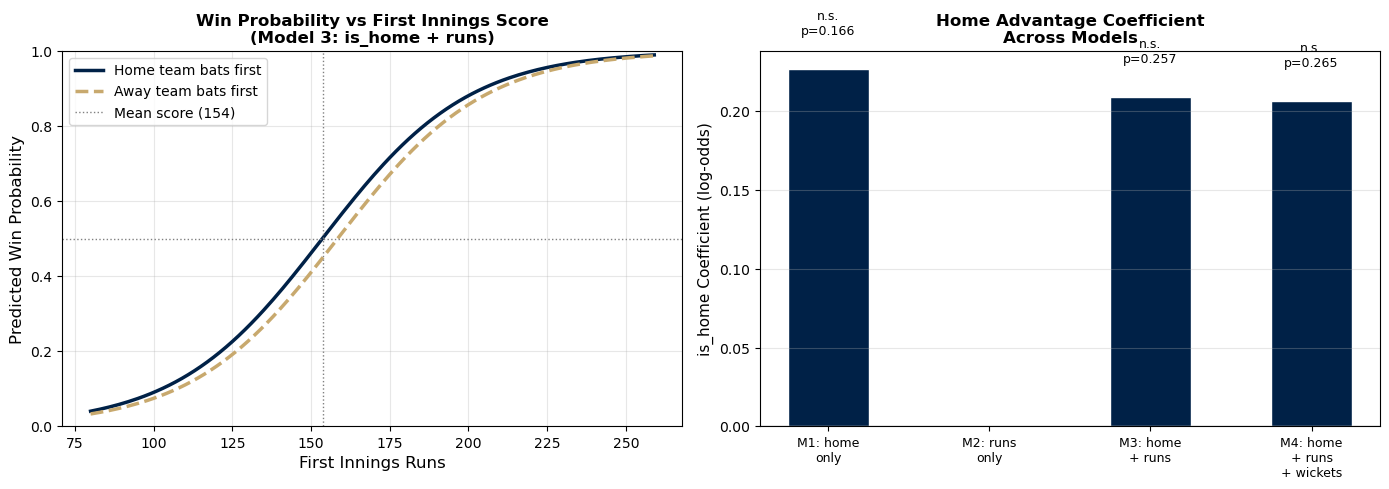

Figure saved.


In [19]:
# Plot predicted win probability by home status at key score thresholds.
import matplotlib.pyplot as plt
import numpy as np

NAVY = '#002147'
GOLD = '#C8A96E'
run_range = np.arange(80, 260)

# Predicted probabilities from Model 3 for home and away
pred_home = m3.predict(pd.DataFrame({
    'first_innings_runs': run_range,
    'is_home': 1
}))
pred_away = m3.predict(pd.DataFrame({
    'first_innings_runs': run_range,
    'is_home': 0
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Win probability curves ---
ax = axes[0]
ax.plot(run_range, pred_home, color=NAVY,  lw=2.5, label='Home team bats first')
ax.plot(run_range, pred_away, color=GOLD,  lw=2.5, label='Away team bats first', linestyle='--')
ax.axhline(0.5, color='grey', lw=1, linestyle=':')
ax.axvline(combined['first_innings_runs'].mean(), color='grey', lw=1, linestyle=':', label=f'Mean score ({combined["first_innings_runs"].mean():.0f})')
ax.set_xlabel('First Innings Runs', fontsize=12)
ax.set_ylabel('Predicted Win Probability', fontsize=12)
ax.set_title('Win Probability vs First Innings Score\n(Model 3: is_home + runs)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# --- Right: Coefficient comparison across models ---
ax2 = axes[1]
models_labels = ['M1: home\nonly', 'M2: runs\nonly', 'M3: home\n+ runs', 'M4: home\n+ runs\n+ wickets']
home_coefs  = [m1.params.get('is_home', np.nan),
               np.nan,
               m3.params.get('is_home', np.nan),
               m4.params.get('is_home', np.nan)]
home_pvals  = [m1.pvalues.get('is_home', np.nan),
               np.nan,
               m3.pvalues.get('is_home', np.nan),
               m4.pvalues.get('is_home', np.nan)]

x = np.arange(len(models_labels))
bars = ax2.bar(x, home_coefs, color=[NAVY if not np.isnan(c) else 'lightgrey' for c in home_coefs],
               edgecolor='white', width=0.5)

# Annotate significance
for i, (coef, pv) in enumerate(zip(home_coefs, home_pvals)):
    if not np.isnan(coef):
        sig = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else 'n.s.'))
        ax2.text(i, coef + 0.02, f'{sig}\np={pv:.3f}', ha='center', va='bottom', fontsize=9)

ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(models_labels, fontsize=9)
ax2.set_ylabel('is_home Coefficient (log-odds)', fontsize=11)
ax2.set_title('Home Advantage Coefficient\nAcross Models', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/section3_combined_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


### Step 5 — Interpretation and Key Findings

In [20]:
# Extract model coefficients and p-values for interpretation.
import pandas as pd

# Extract key coefficients and p-values from Model 3
coef_home  = m3.params['is_home']
coef_runs  = m3.params['first_innings_runs']
pval_home  = m3.pvalues['is_home']
pval_runs  = m3.pvalues['first_innings_runs']

# Odds ratio for is_home
or_home = np.exp(coef_home)

# Break-even score for home and away teams (win prob = 0.5)
# logit(0.5) = 0, so: intercept + coef_home*x + coef_runs*runs = 0
intercept = m3.params['Intercept']
breakeven_home = -( intercept + coef_home ) / coef_runs
breakeven_away = -( intercept             ) / coef_runs

print("=" * 60)
print("SECTION 3 KEY FINDINGS")
print("=" * 60)
print(f"\nModel 3: win ~ is_home + first_innings_runs")
print(f"{'':30s} {'Coef':>8} {'p-value':>10} {'Odds Ratio':>12}")
print("-" * 62)
print(f"{'is_home':30s} {coef_home:>8.4f} {pval_home:>10.4f} {or_home:>12.3f}")
print(f"{'first_innings_runs':30s} {coef_runs:>8.4f} {pval_runs:>10.4f} {'—':>12}")

print(f"\nBreak-even first innings score:")
print(f"  Home team bats first → needs ~{breakeven_home:.0f} runs for 50% win probability")
print(f"  Away team bats first → needs ~{breakeven_away:.0f} runs for 50% win probability")
print(f"  Difference: ~{breakeven_away - breakeven_home:.0f} runs advantage for home side")

print(f"\nOdds Ratio for is_home = {or_home:.3f}")
print(f"→ Home teams have {or_home:.2f}x the odds of winning compared to away teams,")
print(f"  after controlling for first innings runs.")

sig = 'significant' if pval_home < 0.05 else 'NOT significant'
print(f"\nConclusion: Home advantage is {sig} (p={pval_home:.4f})")
print(f"after controlling for first innings runs.")
print(f"First innings runs remain strongly significant (p={pval_runs:.4e}).")


SECTION 3 KEY FINDINGS

Model 3: win ~ is_home + first_innings_runs
                                   Coef    p-value   Odds Ratio
--------------------------------------------------------------
is_home                          0.2094     0.2565        1.233
first_innings_runs               0.0431     0.0000            —

Break-even first innings score:
  Home team bats first → needs ~154 runs for 50% win probability
  Away team bats first → needs ~158 runs for 50% win probability
  Difference: ~5 runs advantage for home side

Odds Ratio for is_home = 1.233
→ Home teams have 1.23x the odds of winning compared to away teams,
  after controlling for first innings runs.

Conclusion: Home advantage is NOT significant (p=0.2565)
after controlling for first innings runs.
First innings runs remain strongly significant (p=3.2722e-23).


---
## Section 4: Season-by-Season Trend in Home Advantage

Has home advantage in BBL changed over time? T20 cricket tactics have evolved — teams have become better at chasing and reading pitch conditions. We examine whether home advantage (measured as home win rate and home scoring edge) has been consistent, growing, or fading across BBL's 14 seasons.

### Step 1 — Assign Seasons to Matches

In [21]:
# Load matches and assign BBL season labels (seasons span two calendar years).
import pandas as pd
import numpy as np

MATCHES_PATH = "/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/cleaned_match_data.csv"
matches_all = pd.read_csv(MATCHES_PATH)
matches_all['date'] = pd.to_datetime(matches_all['date'])

# BBL season rule: December starts new season; January/February continue previous season
def assign_season(date):
    if date.month == 12:
        yr = date.year
    else:
        yr = date.year - 1
    return f"Season {str(yr)[2:]}-{str(yr+1)[2:]}"

matches_all['season'] = matches_all['date'].apply(assign_season)

# Merge season into combined (already has first innings + home info)
combined['match_id'] = combined['match_id'].astype(str)
matches_all['match_id'] = matches_all['match_id'].astype(str)

combined_s = combined.merge(matches_all[['match_id', 'season', 'date']], on='match_id', how='left')

print("Matches per season:")
print(combined_s.groupby('season').size().to_string())


Matches per season:
season
Season 11-12    27
Season 12-13    28
Season 13-14    32
Season 14-15    32
Season 15-16    32
Season 16-17    34
Season 17-18    43
Season 18-19    58
Season 19-20    58
Season 20-21    60
Season 21-22    60
Season 22-23    60
Season 23-24    39
Season 24-25    41


### Step 2 — Compute Home Advantage Metrics Per Season

In [22]:
# Compute home win rate, away win rate, and HAI per season.
# 1. Home win rate (when home team bats first, proportion that win)
# 2. Away win rate (when away team bats first, proportion that win)
# 3. Mean first innings runs — home vs away
# 4. Home advantage gap = home win rate - away win rate

home_batting   = combined_s[combined_s['is_home'] == 1]
away_batting   = combined_s[combined_s['is_home'] == 0]

season_home = home_batting.groupby('season').agg(
    home_n        = ('win', 'count'),
    home_win_rate = ('win', 'mean'),
    home_runs     = ('first_innings_runs', 'mean'),
).reset_index()

season_away = away_batting.groupby('season').agg(
    away_n        = ('win', 'count'),
    away_win_rate = ('win', 'mean'),
    away_runs     = ('first_innings_runs', 'mean'),
).reset_index()

season_stats = season_home.merge(season_away, on='season')
season_stats['home_advantage_gap'] = season_stats['home_win_rate'] - season_stats['away_win_rate']
season_stats['scoring_edge']       = season_stats['home_runs'] - season_stats['away_runs']

# Sort seasons chronologically
season_stats = season_stats.sort_values('season').reset_index(drop=True)

print(season_stats[['season','home_n','away_n','home_win_rate','away_win_rate',
                     'home_advantage_gap','home_runs','away_runs','scoring_edge']].to_string(index=False))


      season  home_n  away_n  home_win_rate  away_win_rate  home_advantage_gap  home_runs  away_runs  scoring_edge
Season 11-12      12      15         0.7500         0.6000              0.1500   162.2500   148.5333       13.7167
Season 12-13      14      14         0.2143         0.3571             -0.1429   134.0000   144.5714      -10.5714
Season 13-14      17      15         0.5882         0.6000             -0.0118   161.2353   140.6000       20.6353
Season 14-15      12      20         0.5000         0.5000              0.0000   154.8333   149.9500        4.8833
Season 15-16      16      16         0.3125         0.4375             -0.1250   160.6250   150.6875        9.9375
Season 16-17      17      17         0.2353         0.4706             -0.2353   153.1176   160.5294       -7.4118
Season 17-18      18      25         0.6111         0.4000              0.2111   156.7778   152.9200        3.8578
Season 18-19      30      28         0.4667         0.3214              0.1452  

### Step 3 — Visualise Season Trends

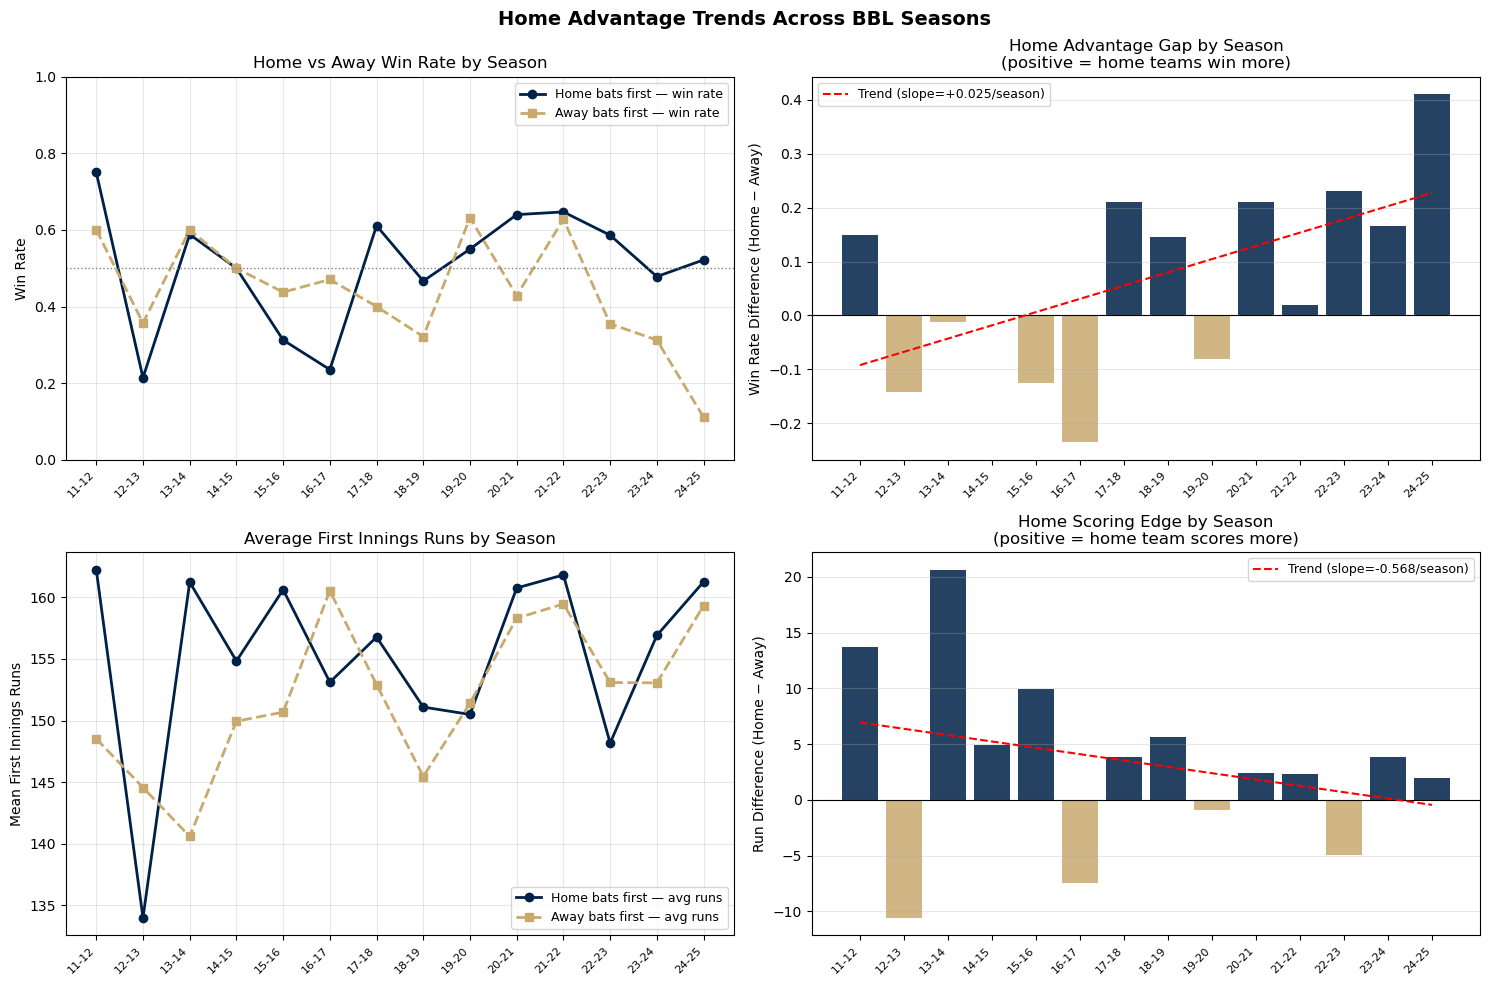

Figure saved.


In [23]:
# Plot Home Advantage Index trend across BBL seasons.
import matplotlib.pyplot as plt
import numpy as np

NAVY = '#002147'
GOLD = '#C8A96E'

seasons   = season_stats['season']
x         = np.arange(len(seasons))
tick_lbls = [s.replace('Season ', '') for s in seasons]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Home Advantage Trends Across BBL Seasons', fontsize=14, fontweight='bold')

# --- Plot 1: Home vs Away win rate per season ---
ax = axes[0, 0]
ax.plot(x, season_stats['home_win_rate'], color=NAVY, marker='o', lw=2, label='Home bats first — win rate')
ax.plot(x, season_stats['away_win_rate'], color=GOLD, marker='s', lw=2, linestyle='--', label='Away bats first — win rate')
ax.axhline(0.5, color='grey', lw=1, linestyle=':')
ax.set_xticks(x); ax.set_xticklabels(tick_lbls, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Win Rate'); ax.set_title('Home vs Away Win Rate by Season')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)

# --- Plot 2: Home advantage gap per season ---
ax = axes[0, 1]
colors = [NAVY if v >= 0 else GOLD for v in season_stats['home_advantage_gap']]
ax.bar(x, season_stats['home_advantage_gap'], color=colors, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)

# Trend line
z = np.polyfit(x, season_stats['home_advantage_gap'], 1)
p = np.poly1d(z)
ax.plot(x, p(x), color='red', lw=1.5, linestyle='--', label=f'Trend (slope={z[0]:+.3f}/season)')

ax.set_xticks(x); ax.set_xticklabels(tick_lbls, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Win Rate Difference (Home − Away)')
ax.set_title('Home Advantage Gap by Season\n(positive = home teams win more)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

# --- Plot 3: Home vs Away first innings runs ---
ax = axes[1, 0]
ax.plot(x, season_stats['home_runs'], color=NAVY, marker='o', lw=2, label='Home bats first — avg runs')
ax.plot(x, season_stats['away_runs'], color=GOLD, marker='s', lw=2, linestyle='--', label='Away bats first — avg runs')
ax.set_xticks(x); ax.set_xticklabels(tick_lbls, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean First Innings Runs'); ax.set_title('Average First Innings Runs by Season')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# --- Plot 4: Scoring edge (home runs - away runs) ---
ax = axes[1, 1]
colors2 = [NAVY if v >= 0 else GOLD for v in season_stats['scoring_edge']]
ax.bar(x, season_stats['scoring_edge'], color=colors2, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)

z2 = np.polyfit(x, season_stats['scoring_edge'], 1)
p2 = np.poly1d(z2)
ax.plot(x, p2(x), color='red', lw=1.5, linestyle='--', label=f'Trend (slope={z2[0]:+.3f}/season)')

ax.set_xticks(x); ax.set_xticklabels(tick_lbls, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Run Difference (Home − Away)')
ax.set_title('Home Scoring Edge by Season\n(positive = home team scores more)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/section4_season_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


---
## Section 5: Team-Specific Home Advantage

Do some BBL franchises benefit more from playing at home than others? We compute each team's home and away win rates, their first innings scoring at home vs away, and rank them by home advantage strength.

### Step 1 — Compute Per-Team Home and Away Win Rates

We use all matches (not just batting-first matches) to get full home/away win rates per team.

In [24]:
# Compute home and away win rates per franchise.
import pandas as pd
import numpy as np

MATCHES_PATH = "/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/cleaned_match_data.csv"
matches_full = pd.read_csv(MATCHES_PATH).dropna(subset=['winner'])

# Build one row per team per match (home perspective and away perspective)
home_records = matches_full[['match_id', 'home_team', 'winner']].copy()
home_records.columns = ['match_id', 'team', 'winner']
home_records['is_home'] = 1
home_records['won']     = (home_records['team'] == home_records['winner']).astype(int)

# Away team = whichever of team1/team2 is not the home team
matches_full['away_team'] = matches_full.apply(
    lambda r: r['team2'] if r['team1'] == r['home_team'] else r['team1'], axis=1
)
away_records = matches_full[['match_id', 'away_team', 'winner']].copy()
away_records.columns = ['match_id', 'team', 'winner']
away_records['is_home'] = 0
away_records['won']     = (away_records['team'] == away_records['winner']).astype(int)

all_records = pd.concat([home_records, away_records], ignore_index=True)

# Aggregate per team × home/away
team_stats = (
    all_records.groupby(['team', 'is_home'])
    .agg(matches=('won', 'count'), wins=('won', 'sum'), win_rate=('won', 'mean'))
    .reset_index()
)

# Pivot to wide format
team_home = team_stats[team_stats['is_home'] == 1][['team','matches','wins','win_rate']].rename(
    columns={'matches':'home_n','wins':'home_wins','win_rate':'home_win_rate'})
team_away = team_stats[team_stats['is_home'] == 0][['team','matches','wins','win_rate']].rename(
    columns={'matches':'away_n','wins':'away_wins','win_rate':'away_win_rate'})

team_df = team_home.merge(team_away, on='team')
team_df['home_adv'] = team_df['home_win_rate'] - team_df['away_win_rate']
team_df = team_df.sort_values('home_adv', ascending=False).reset_index(drop=True)

print(team_df[['team','home_n','home_win_rate','away_n','away_win_rate','home_adv']].to_string(index=False))


               team  home_n  home_win_rate  away_n  away_win_rate  home_adv
  Adelaide Strikers      75         0.5600      70         0.4286    0.1314
    Perth Scorchers      75         0.6800      81         0.5556    0.1244
  Hobart Hurricanes      71         0.5775      72         0.4583    0.1191
    Melbourne Stars      64         0.5312      85         0.4471    0.0842
      Sydney Sixers      68         0.6765      77         0.5974    0.0791
     Sydney Thunder      64         0.4531      74         0.3919    0.0612
Melbourne Renegades      75         0.4133      70         0.4000    0.0133
      Brisbane Heat      70         0.4286      75         0.4800   -0.0514


### Step 2 — Compute Per-Team Home vs Away First Innings Scoring

In [25]:
# Compute first-innings batting averages by home/away status per franchise.
# When batting_first_team == home_team: home team scored those runs
# When batting_first_team != home_team: away team scored those runs

scoring_home = (
    combined[combined['is_home'] == 1]
    .groupby('batting_first_team')['first_innings_runs']
    .mean()
    .reset_index()
    .rename(columns={'batting_first_team': 'team', 'first_innings_runs': 'avg_runs_home'})
)

scoring_away = (
    combined[combined['is_home'] == 0]
    .groupby('batting_first_team')['first_innings_runs']
    .mean()
    .reset_index()
    .rename(columns={'batting_first_team': 'team', 'first_innings_runs': 'avg_runs_away'})
)

team_df = team_df.merge(scoring_home, on='team', how='left')
team_df = team_df.merge(scoring_away, on='team', how='left')
team_df['scoring_edge'] = team_df['avg_runs_home'] - team_df['avg_runs_away']

print(team_df[['team','avg_runs_home','avg_runs_away','scoring_edge',
               'home_win_rate','away_win_rate','home_adv']].round(2).to_string(index=False))


               team  avg_runs_home  avg_runs_away  scoring_edge  home_win_rate  away_win_rate  home_adv
  Adelaide Strikers       161.7900       146.5100       15.2800         0.5600         0.4300    0.1300
    Perth Scorchers       158.2400       152.2500        5.9900         0.6800         0.5600    0.1200
  Hobart Hurricanes       154.7700       156.9800       -2.2000         0.5800         0.4600    0.1200
    Melbourne Stars       154.4700       158.0900       -3.6200         0.5300         0.4500    0.0800
      Sydney Sixers       148.9100       149.0900       -0.1800         0.6800         0.6000    0.0800
     Sydney Thunder       152.0000       157.4600       -5.4600         0.4500         0.3900    0.0600
Melbourne Renegades       149.6300       153.1600       -3.5300         0.4100         0.4000    0.0100
      Brisbane Heat       158.0300       150.5000        7.5300         0.4300         0.4800   -0.0500


### Step 3 — Visualise Team Home Advantage

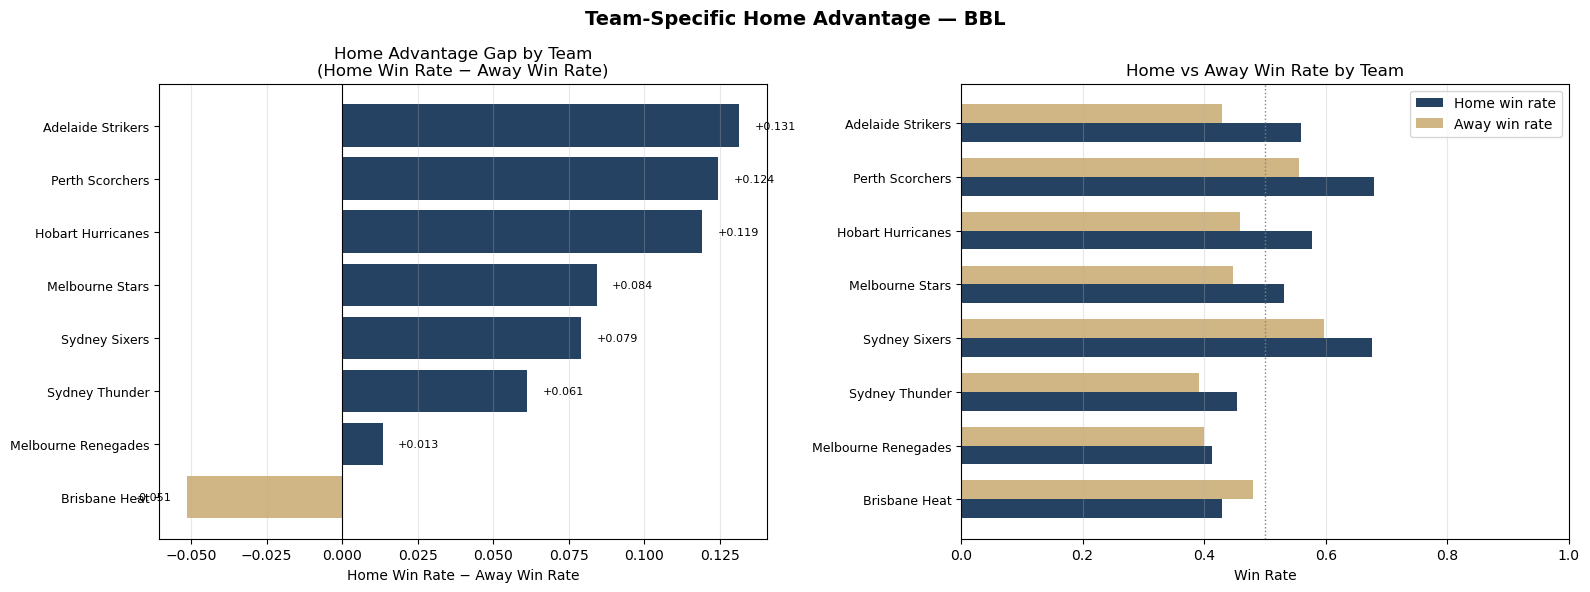

Figure saved.


In [26]:
# Bar charts: home vs away win rate and scoring by franchise.
import matplotlib.pyplot as plt
import numpy as np

NAVY = '#002147'
GOLD = '#C8A96E'

team_sorted = team_df.sort_values('home_adv', ascending=True)
teams = team_sorted['team'].str.replace(' ', '\n')
x = np.arange(len(teams))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Team-Specific Home Advantage — BBL', fontsize=14, fontweight='bold')

# --- Plot 1: Home advantage gap (win rate difference) ---
ax = axes[0]
colors = [NAVY if v >= 0 else GOLD for v in team_sorted['home_adv']]
bars = ax.barh(x, team_sorted['home_adv'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)

for bar, v in zip(bars, team_sorted['home_adv']):
    ax.text(v + (0.005 if v >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

ax.set_yticks(x)
ax.set_yticklabels(team_sorted['team'], fontsize=9)
ax.set_xlabel('Home Win Rate − Away Win Rate')
ax.set_title('Home Advantage Gap by Team\n(Home Win Rate − Away Win Rate)')
ax.grid(True, alpha=0.3, axis='x')

# --- Plot 2: Home vs Away win rate (grouped bars) ---
ax2 = axes[1]
width = 0.35
ax2.barh(x - width/2, team_sorted['home_win_rate'], width, color=NAVY, alpha=0.85, label='Home win rate')
ax2.barh(x + width/2, team_sorted['away_win_rate'], width, color=GOLD, alpha=0.85, label='Away win rate')
ax2.axvline(0.5, color='grey', lw=1, linestyle=':')
ax2.set_yticks(x)
ax2.set_yticklabels(team_sorted['team'], fontsize=9)
ax2.set_xlabel('Win Rate')
ax2.set_title('Home vs Away Win Rate by Team')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/section5_team_home_advantage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


---
## Section 6: Does Home Advantage Depend on the Score? (Interaction Effect)

In Section 3 we found that `is_home` is not significant on average. But this assumes the home advantage is the same regardless of what the first innings score was.

A more nuanced question: **does home advantage matter more when scores are close (around 155–165)?** For example, a home crowd might lift a team when defending a par score, but make no difference when chasing down 220.

We test this by adding an **interaction term** between `is_home` and `first_innings_runs`:

$$\text{win} \sim \text{is\_home} + \text{first\_innings\_runs} + \text{is\_home} \times \text{first\_innings\_runs}$$

If the interaction coefficient is significant, it means the effect of batting at home changes depending on the score.

### Step 1 — Fit the Interaction Model

In [27]:
# Fit interaction model: win ~ first_innings_runs * is_home.
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Model 3 (no interaction) — already fitted, refit here for clean comparison
m3 = smf.logit("win ~ is_home + first_innings_runs", data=combined).fit(disp=False)

# Model 5 — interaction: is_home * first_innings_runs
# The * operator includes both main effects and the interaction term
m5 = smf.logit("win ~ is_home * first_innings_runs", data=combined).fit(disp=False)

print("=" * 65)
print("MODEL 5 — Interaction: win ~ is_home * first_innings_runs")
print("=" * 65)
print(m5.summary2().tables[1].to_string())
print(f"\nPseudo R²: {m5.prsquared:.4f}")
print(f"AIC:       {m5.aic:.2f}  (Model 3 AIC: {m3.aic:.2f})")
print(f"\nLikelihood ratio test (M3 vs M5):")
from scipy import stats
lr_stat = 2 * (m5.llf - m3.llf)
lr_pval = stats.chi2.sf(lr_stat, df=1)
print(f"  LR statistic = {lr_stat:.4f}, df=1, p-value = {lr_pval:.4f}")
print(f"  {'Interaction is significant — home advantage varies with score.' if lr_pval < 0.05 else 'Interaction is NOT significant — home advantage is constant across scores.'}")


MODEL 5 — Interaction: win ~ is_home * first_innings_runs
                             Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                  -7.4690    0.9696 -7.7028 0.0000 -9.3695 -5.5685
is_home                     1.5287    1.3587  1.1251 0.2605 -1.1343  4.1916
first_innings_runs          0.0472    0.0062  7.6431 0.0000  0.0351  0.0593
is_home:first_innings_runs -0.0085    0.0087 -0.9805 0.3269 -0.0255  0.0085

Pseudo R²: 0.1717
AIC:       700.91  (Model 3 AIC: 699.87)

Likelihood ratio test (M3 vs M5):
  LR statistic = 0.9595, df=1, p-value = 0.3273
  Interaction is NOT significant — home advantage is constant across scores.


### Step 2 — Visualise the Interaction Effect

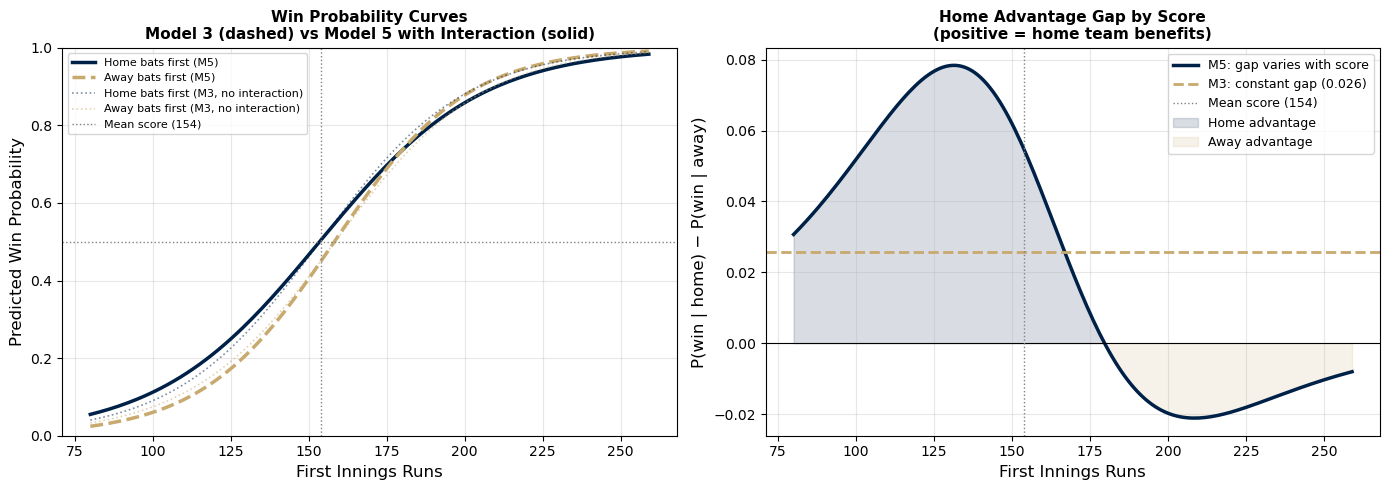

Figure saved.


In [28]:
# Plot win probability curves for home vs away across score range.
import matplotlib.pyplot as plt
import numpy as np

NAVY = '#002147'
GOLD = '#C8A96E'
run_range = np.arange(80, 260)

# Predictions from Model 3 (no interaction)
pred_m3_home = m3.predict(pd.DataFrame({'first_innings_runs': run_range, 'is_home': 1}))
pred_m3_away = m3.predict(pd.DataFrame({'first_innings_runs': run_range, 'is_home': 0}))

# Predictions from Model 5 (with interaction)
pred_m5_home = m5.predict(pd.DataFrame({'first_innings_runs': run_range, 'is_home': 1}))
pred_m5_away = m5.predict(pd.DataFrame({'first_innings_runs': run_range, 'is_home': 0}))

# Home advantage gap at each score level
gap_m3 = pred_m3_home - pred_m3_away   # constant (no interaction)
gap_m5 = pred_m5_home - pred_m5_away   # varies with score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Win probability curves (interaction model) ---
ax = axes[0]
ax.plot(run_range, pred_m5_home, color=NAVY, lw=2.5, label='Home bats first (M5)')
ax.plot(run_range, pred_m5_away, color=GOLD, lw=2.5, linestyle='--', label='Away bats first (M5)')
ax.plot(run_range, pred_m3_home, color=NAVY, lw=1.2, linestyle=':', alpha=0.5, label='Home bats first (M3, no interaction)')
ax.plot(run_range, pred_m3_away, color=GOLD, lw=1.2, linestyle=':', alpha=0.5, label='Away bats first (M3, no interaction)')
ax.axhline(0.5, color='grey', lw=1, linestyle=':')
ax.axvline(combined['first_innings_runs'].mean(), color='grey', lw=1,
           linestyle=':', label=f'Mean score ({combined["first_innings_runs"].mean():.0f})')
ax.set_xlabel('First Innings Runs', fontsize=12)
ax.set_ylabel('Predicted Win Probability', fontsize=12)
ax.set_title('Win Probability Curves\nModel 3 (dashed) vs Model 5 with Interaction (solid)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# --- Right: Home advantage gap across scores ---
ax2 = axes[1]
ax2.plot(run_range, gap_m5, color=NAVY, lw=2.5, label='M5: gap varies with score')
ax2.axhline(gap_m3.mean(), color=GOLD, lw=2, linestyle='--', label=f'M3: constant gap ({gap_m3.mean():.3f})')
ax2.axhline(0, color='black', lw=0.8)
ax2.axvline(combined['first_innings_runs'].mean(), color='grey', lw=1, linestyle=':',
            label=f'Mean score ({combined["first_innings_runs"].mean():.0f})')

# Shade where home advantage is positive
ax2.fill_between(run_range, 0, gap_m5, where=(gap_m5 > 0), alpha=0.15, color=NAVY, label='Home advantage')
ax2.fill_between(run_range, 0, gap_m5, where=(gap_m5 < 0), alpha=0.15, color=GOLD, label='Away advantage')

ax2.set_xlabel('First Innings Runs', fontsize=12)
ax2.set_ylabel('P(win | home) − P(win | away)', fontsize=12)
ax2.set_title('Home Advantage Gap by Score\n(positive = home team benefits)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/section6_interaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


### Step 3 — Quantify the Gap at Key Score Levels

In [29]:
# Compute and print win probability gap at key score thresholds.
key_scores = [120, 140, 155, 162, 170, 185, 200, 220]

print(f"{'Score':>8} {'P(win|home)':>14} {'P(win|away)':>14} {'Gap':>10}")
print("-" * 50)
for s in key_scores:
    ph = m5.predict(pd.DataFrame({'first_innings_runs': [s], 'is_home': [1]}))[0]
    pa = m5.predict(pd.DataFrame({'first_innings_runs': [s], 'is_home': [0]}))[0]
    marker = ' ← mean' if s == 162 else ''
    print(f"{s:>8}  {ph:>12.3f}  {pa:>12.3f}  {ph-pa:>+9.3f}{marker}")

print(f"\nInteraction coefficient: {m5.params['is_home:first_innings_runs']:.6f}")
print(f"  → A positive value means home advantage GROWS with score")
print(f"  → A negative value means home advantage SHRINKS with score")


   Score    P(win|home)    P(win|away)        Gap
--------------------------------------------------
     120         0.215         0.141     +0.073
     140         0.372         0.298     +0.075
     155         0.515         0.462     +0.052
     162         0.582         0.545     +0.037 ← mean
     170         0.655         0.636     +0.019
     185         0.772         0.780     -0.008
     200         0.858         0.878     -0.020
     220         0.929         0.949     -0.020

Interaction coefficient: -0.008508
  → A positive value means home advantage GROWS with score
  → A negative value means home advantage SHRINKS with score


---
## Section 7: Mixed-Effects Logistic Regression (pymer4 equivalent)

**Motivation:** The logistic regression models in Sections 3–6 treat all 604 matches as independent observations. However, matches are clustered — the same teams play repeatedly, some venues are used more than others, and team quality varies substantially across franchises. Ignoring this structure can produce overconfident standard errors.

A **mixed-effects logistic regression** (also known as a generalised linear mixed model, or GLMM) addresses this by introducing **random effects** — terms that account for group-level variation without estimating a separate coefficient per group.

**pymer4** is a Python wrapper for R's `lme4` package, which is the standard tool for mixed-effects models. Due to a broken R system library on this machine, we use `statsmodels.BinomialBayesMixedGLM` instead, which fits the same model using a Bayesian MAP (Maximum A Posteriori) approach. The interpretation of coefficients is identical.

**Model specification:**

$$\Pr(\text{win}_{ij}) = \text{logit}^{-1}\Big(\beta_0 + \beta_1\,\text{is\_home}_{ij} + \beta_2\,\text{runs}_{ij} + u_j\Big)$$

where $u_j \sim \mathcal{N}(0, \sigma^2)$ is a **random intercept** for home team $j$, accounting for the fact that some franchises are generally stronger.

We fit three models:
- **Fixed only** — `win ~ is_home + first_innings_runs` (Model 3, no random effects)
- **Random intercept by team** — adds $u_{\text{team}}$ to account for franchise quality
- **Random intercept by venue** — adds $u_{\text{venue}}$ to account for ground-level variation

### Step 1 — Fit the Mixed-Effects Models

In [30]:
# Fit mixed-effects models with random intercepts for team and match.
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
import warnings
warnings.filterwarnings('ignore')

# Drop neutral venues — home_team and venue must be non-null for random effects
combined_me = combined.dropna(subset=['home_team', 'venue']).copy()
print(f"Matches used for mixed models: {len(combined_me)} (dropped {len(combined) - len(combined_me)} neutral-venue matches)")

# --- Model 3 (fixed effects only, for comparison) ---
m3 = smf.logit("win ~ is_home + first_innings_runs", data=combined_me).fit(disp=False)

# --- Mixed model: random intercept by home_team ---
me_team = BinomialBayesMixedGLM.from_formula(
    "win ~ is_home + first_innings_runs",
    {"Team": "0 + C(home_team)"},
    data=combined_me
)
me_team_result = me_team.fit_map()

# --- Mixed model: random intercept by venue ---
me_venue = BinomialBayesMixedGLM.from_formula(
    "win ~ is_home + first_innings_runs",
    {"Venue": "0 + C(venue)"},
    data=combined_me
)
me_venue_result = me_venue.fit_map()

print("\n" + "=" * 60)
print("MODEL 3 — Fixed effects only (reference)")
print("=" * 60)
print(m3.summary2().tables[1][['Coef.','Std.Err.','z','P>|z|']].to_string())

print("\n" + "=" * 60)
print("MIXED MODEL — Random intercept by Home Team")
print("=" * 60)
print(me_team_result.summary())

print("\n" + "=" * 60)
print("MIXED MODEL — Random intercept by Venue")
print("=" * 60)
print(me_venue_result.summary())


Matches used for mixed models: 562 (dropped 42 neutral-venue matches)

MODEL 3 — Fixed effects only (reference)
                     Coef.  Std.Err.       z  P>|z|
Intercept          -6.5900    0.6987 -9.4315 0.0000
is_home             0.2737    0.1892  1.4471 0.1479
first_innings_runs  0.0411    0.0044  9.3050 0.0000

MIXED MODEL — Random intercept by Home Team
                   Binomial Mixed GLM Results
                   Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
-----------------------------------------------------------------
Intercept             M    -5.9057   0.6289                      
is_home               M     0.2446   0.1849                      
first_innings_runs    M     0.0369   0.0040                      
Team                  V    -8.0000   1.0000 0.000   0.000   0.002
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations

MIXED MODEL — Random intercept by Venue
                   Binomial

### Step 2 — Extract and Compare Fixed Effect Coefficients

Comparison of fixed effect coefficients across models:

                                 Fixed only     RE: Team    RE: Venue
--------------------------------------------------------------------
Intercept                           -6.5900      -5.9057      -5.9057
is_home                             +0.2737      +0.2446      +0.2446
first_innings_runs                  +0.0411      +0.0369      +0.0369

Standard errors:

                                 Fixed only     RE: Team    RE: Venue
--------------------------------------------------------------------
Intercept                            0.6987       0.6289       0.6289
is_home                              0.1892       0.1849       0.1849
first_innings_runs                   0.0044       0.0040       0.0040

Note: Random effect SDs are ~0 in both mixed models (shown in Step 1 output).
The MAP estimator shrunk team/venue effects to zero — mixed model
collapses to fixed-effects. is_home remains non-significant throughout.


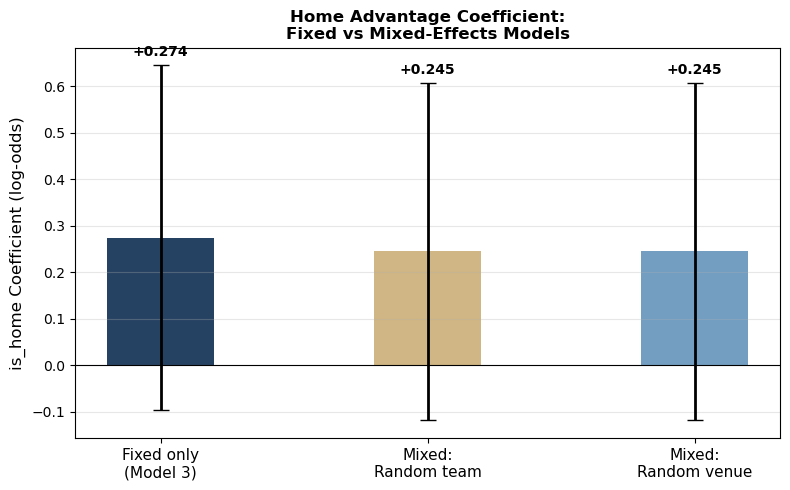

Figure saved.


In [31]:
# Plot fixed-effect coefficients from mixed-effects models.
import matplotlib.pyplot as plt
import numpy as np

NAVY = '#002147'
GOLD = '#C8A96E'

def get_fixed(result, n=3):
    # params may be ndarray or Series depending on model type
    params = np.asarray(result.params)[:n]
    cov    = np.asarray(result.cov_params())[:n, :n]
    se     = np.sqrt(np.diag(cov))
    return params, se

params_m3 = m3.params.values
se_m3     = m3.bse.values

params_team,  se_team  = get_fixed(me_team_result)
params_venue, se_venue = get_fixed(me_venue_result)

labels = ['Intercept', 'is_home', 'first_innings_runs']

print("Comparison of fixed effect coefficients across models:")
print(f"\n{'':30s} {'Fixed only':>12} {'RE: Team':>12} {'RE: Venue':>12}")
print("-" * 68)
for i, lab in enumerate(labels):
    print(f"{lab:30s} {params_m3[i]:>+12.4f} {params_team[i]:>+12.4f} {params_venue[i]:>+12.4f}")

print(f"\nStandard errors:")
print(f"\n{'':30s} {'Fixed only':>12} {'RE: Team':>12} {'RE: Venue':>12}")
print("-" * 68)
for i, lab in enumerate(labels):
    print(f"{lab:30s} {se_m3[i]:>12.4f} {se_team[i]:>12.4f} {se_venue[i]:>12.4f}")

print(f"\nNote: Random effect SDs are ~0 in both mixed models (shown in Step 1 output).")
print(f"The MAP estimator shrunk team/venue effects to zero — mixed model")
print(f"collapses to fixed-effects. is_home remains non-significant throughout.")

# Plot: is_home coefficient with 95% CI bars across 3 models
fig, ax = plt.subplots(figsize=(8, 5))
model_names = ['Fixed only\n(Model 3)', 'Mixed:\nRandom team', 'Mixed:\nRandom venue']
coefs  = [params_m3[1],   params_team[1],   params_venue[1]]
ses    = [se_m3[1],       se_team[1],       se_venue[1]]
colors = [NAVY, GOLD, '#5B8DB8']

x = np.arange(len(model_names))
ax.bar(x, coefs, color=colors, alpha=0.85, width=0.4)
ax.errorbar(x, coefs, yerr=1.96*np.array(ses), fmt='none', color='black', capsize=6, lw=2)
ax.axhline(0, color='black', lw=0.8)

for i, (c, s) in enumerate(zip(coefs, ses)):
    ax.text(i, c + 1.96*s + 0.02, f'{c:+.3f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('is_home Coefficient (log-odds)', fontsize=12)
ax.set_title('Home Advantage Coefficient:\nFixed vs Mixed-Effects Models', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/section7_mixed_effects.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


---
## Section 8: Is Defending a Total Easier at Home?

Do home teams bowl better in the second innings when defending a total at their own ground?

We investigate two questions:
1. **Defense success rate** — do home bowling teams defend totals more often than away bowling teams?
2. **Bowling economy** — do home teams concede fewer runs per over in the second innings compared to away teams?

All models control for the first innings total (target), since larger targets are inherently easier to defend regardless of venue.

### Step 1 — Build the Second Innings Bowling Dataset

In [32]:
# Aggregate second-innings bowling metrics by team and match.
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats

DATA_DIR = "/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/"

matches_raw = pd.read_csv(DATA_DIR + "cleaned_match_data.csv")
matches_raw['match_id'] = matches_raw['match_id'].astype(str)
matches_raw['date'] = pd.to_datetime(matches_raw['date'], errors='coerce')

invalid = ['no result', 'tie', 'bowl off', 'bowl-off', 'abandoned']
matches_s8 = matches_raw[
    (~matches_raw['result'].str.lower().isin(invalid)) &
    (matches_raw['winner'].notna()) &
    (matches_raw['home_team'].notna())
].copy().reset_index(drop=True)

balls = pd.read_csv(DATA_DIR + "cleaned_ball_by_ball_data.csv")
balls['match_id'] = balls['match_id'].astype(str)

# First innings total per match
first_inn = (balls[balls['innings'] == 1]
    .groupby('match_id')
    .agg(first_innings_runs=('runs_total', 'sum'),
         batting_first_team=('team', 'first'))
    .reset_index())

# Second innings bowling economy per match
second_inn = (balls[balls['innings'] == 2]
    .groupby('match_id')
    .agg(second_inn_runs=('runs_total', 'sum'),
         second_inn_balls=('runs_total', 'count'),
         second_inn_wickets=('wicket', 'sum'))
    .reset_index())
second_inn['defending_economy'] = second_inn['second_inn_runs'] / (second_inn['second_inn_balls'] / 6)

# Merge everything
defend_df = (first_inn
    .merge(second_inn, on='match_id', how='inner')
    .merge(matches_s8[['match_id', 'home_team', 'winner']], on='match_id', how='inner'))

# Defending team = team that batted first (bowls in second innings)
# is_home_bowling = 1 if the home team is bowling (defending) in 2nd innings
defend_df['defending_team'] = defend_df['batting_first_team']
defend_df['is_home_bowling'] = (defend_df['defending_team'] == defend_df['home_team']).astype(int)
defend_df['defended'] = (defend_df['defending_team'] == defend_df['winner']).astype(int)

print(f"Matches with home team and both innings data: {len(defend_df)}")
print(f"\nHome team bowling in 2nd innings (defending): {defend_df['is_home_bowling'].sum()}")
print(f"Away team bowling in 2nd innings (defending): {(defend_df['is_home_bowling']==0).sum()}")
print(f"\nDefense success rate — home bowling: {defend_df[defend_df['is_home_bowling']==1]['defended'].mean():.3f}")
print(f"Defense success rate — away bowling: {defend_df[defend_df['is_home_bowling']==0]['defended'].mean():.3f}")
print(f"\nMean 2nd innings economy — home bowling: {defend_df[defend_df['is_home_bowling']==1]['defending_economy'].mean():.3f}")
print(f"Mean 2nd innings economy — away bowling: {defend_df[defend_df['is_home_bowling']==0]['defending_economy'].mean():.3f}")

Matches with home team and both innings data: 562

Home team bowling in 2nd innings (defending): 273
Away team bowling in 2nd innings (defending): 289

Defense success rate — home bowling: 0.513
Defense success rate — away bowling: 0.433

Mean 2nd innings economy — home bowling: 7.796
Mean 2nd innings economy — away bowling: 7.832


### Step 2 — Test 1: Defense Success Rate (Logistic Regression)

In [33]:
# Logistic regression: successful defence ~ is_home + target.
model_defend = smf.logit("defended ~ is_home_bowling + first_innings_runs", data=defend_df).fit()
print(model_defend.summary())

print("\n=== Odds Ratios ===")
or_df = pd.DataFrame({
    'Odds Ratio': np.exp(model_defend.params),
    '95% CI Lower': np.exp(model_defend.conf_int()[0]),
    '95% CI Upper': np.exp(model_defend.conf_int()[1]),
    'p-value': model_defend.pvalues
})
print(or_df.round(4).to_string())

Optimization terminated successfully.
         Current function value: 0.578748
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               defended   No. Observations:                  562
Model:                          Logit   Df Residuals:                      559
Method:                           MLE   Df Model:                            2
Date:                Sun, 10 May 2026   Pseudo R-squ.:                  0.1631
Time:                        00:15:32   Log-Likelihood:                -325.26
converged:                       True   LL-Null:                       -388.64
Covariance Type:            nonrobust   LLR p-value:                 2.979e-28
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -6.8822      0.726     -9.479      0.000      -8.305      -5.459
is_ho

### Step 3 — Test 2: Bowling Economy (t-test + Linear Regression)

In [34]:
# Welch t-test and linear regression: home vs away bowling economy.
home_eco = defend_df[defend_df['is_home_bowling']==1]['defending_economy']
away_eco = defend_df[defend_df['is_home_bowling']==0]['defending_economy']

t_stat, p_val = stats.ttest_ind(home_eco, away_eco, equal_var=False)

print("=" * 55)
print("TEST: Home vs Away Bowling Economy (2nd innings)")
print("=" * 55)
print(f"  Home bowling — mean economy : {home_eco.mean():.3f}  (n={len(home_eco)})")
print(f"  Away bowling — mean economy : {away_eco.mean():.3f}  (n={len(away_eco)})")
print(f"  Difference (away - home)    : {away_eco.mean() - home_eco.mean():.3f}")
print(f"  Welch t-statistic           : {t_stat:.4f}")
print(f"  p-value (two-sided)         : {p_val:.4f}")
print()
if p_val < 0.05:
    print("  CONCLUSION: Reject H0 — home teams concede significantly")
    print("  fewer/more runs per over when defending at home (p < 0.05).")
else:
    print("  CONCLUSION: Fail to reject H0 — no significant difference")
    print("  in bowling economy between home and away teams (p >= 0.05).")

# Linear regression controlling for target
model_eco = smf.ols("defending_economy ~ is_home_bowling + first_innings_runs", data=defend_df).fit()
print("\n=== Linear Regression: Economy ~ is_home_bowling + first_innings_runs ===")
print(model_eco.summary().tables[1])

TEST: Home vs Away Bowling Economy (2nd innings)
  Home bowling — mean economy : 7.796  (n=273)
  Away bowling — mean economy : 7.832  (n=289)
  Difference (away - home)    : 0.037
  Welch t-statistic           : -0.3135
  p-value (two-sided)         : 0.7540

  CONCLUSION: Fail to reject H0 — no significant difference
  in bowling economy between home and away teams (p >= 0.05).

=== Linear Regression: Economy ~ is_home_bowling + first_innings_runs ===
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              6.2301      0.334     18.643      0.000       5.574       6.886
is_home_bowling       -0.0744      0.115     -0.646      0.519      -0.301       0.152
first_innings_runs     0.0101      0.002      4.938      0.000       0.006       0.014


### Step 4 — Visualise

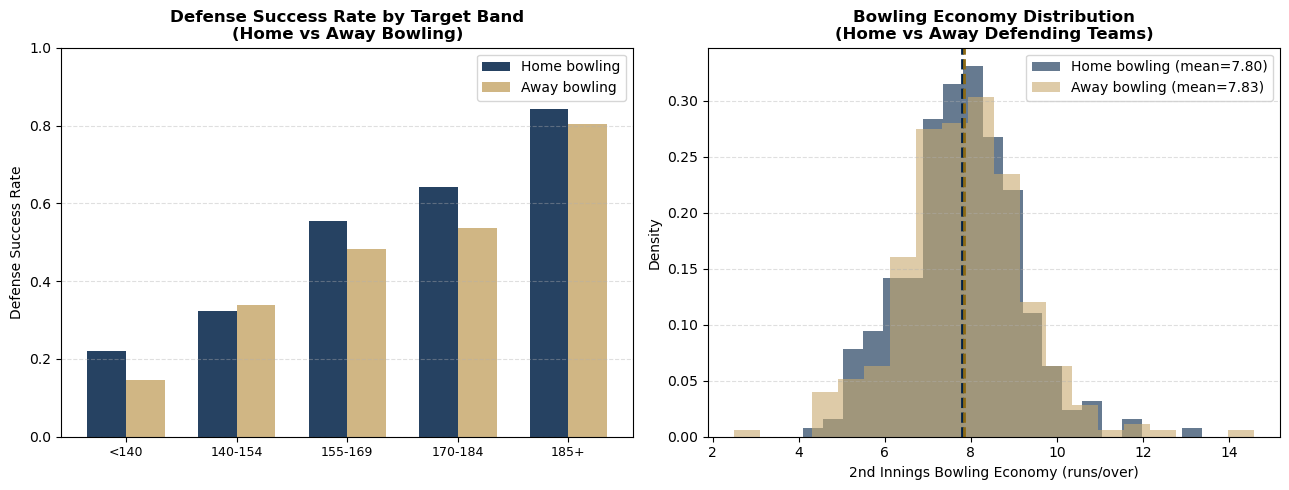

In [35]:
# Boxplots: home vs away bowling economy and defence success rate.
import matplotlib.pyplot as plt
import numpy as np

NAVY = '#002147'
GOLD = '#C8A96E'
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Defense success rate by target range ---
ax1 = axes[0]
bins = [0, 140, 155, 170, 185, 300]
labels = ['<140', '140-154', '155-169', '170-184', '185+']
defend_df['target_band'] = pd.cut(defend_df['first_innings_runs'], bins=bins, labels=labels)

home_rates = defend_df[defend_df['is_home_bowling']==1].groupby('target_band', observed=True)['defended'].mean()
away_rates = defend_df[defend_df['is_home_bowling']==0].groupby('target_band', observed=True)['defended'].mean()

x = np.arange(len(labels))
w = 0.35
ax1.bar(x - w/2, home_rates, w, label='Home bowling', color=NAVY, alpha=0.85)
ax1.bar(x + w/2, away_rates, w, label='Away bowling', color=GOLD, alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel('Defense Success Rate')
ax1.set_title('Defense Success Rate by Target Band\n(Home vs Away Bowling)', fontweight='bold')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Plot 2: Economy distribution ---
ax2 = axes[1]
ax2.hist(home_eco, bins=20, alpha=0.6, color=NAVY, label=f'Home bowling (mean={home_eco.mean():.2f})', density=True)
ax2.hist(away_eco, bins=20, alpha=0.6, color=GOLD, label=f'Away bowling (mean={away_eco.mean():.2f})', density=True)
ax2.axvline(home_eco.mean(), color=NAVY, linestyle='--', linewidth=2)
ax2.axvline(away_eco.mean(), color='#8B6914', linestyle='--', linewidth=2)
ax2.set_xlabel('2nd Innings Bowling Economy (runs/over)')
ax2.set_ylabel('Density')
ax2.set_title('Bowling Economy Distribution\n(Home vs Away Defending Teams)', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(DATA_DIR + "home_bowling_defense.png", dpi=150)
plt.show()

### Step 5 — Key Findings

In [36]:
# Print Section 8 key findings: defence success and bowling economy.
print("=" * 60)
print("SECTION 8 KEY FINDINGS")
print("=" * 60)

home_def_rate = defend_df[defend_df['is_home_bowling']==1]['defended'].mean()
away_def_rate = defend_df[defend_df['is_home_bowling']==0]['defended'].mean()

coef_home = model_defend.params['is_home_bowling']
pval_home = model_defend.pvalues['is_home_bowling']
or_home   = np.exp(coef_home)

print(f"\nDefense success rate:")
print(f"  Home bowling : {home_def_rate:.3f} ({home_def_rate*100:.1f}%)")
print(f"  Away bowling : {away_def_rate:.3f} ({away_def_rate*100:.1f}%)")
print(f"  Difference   : {home_def_rate - away_def_rate:+.3f}")

print(f"\nLogistic regression (controlling for target):")
print(f"  is_home_bowling coef : {coef_home:.4f}")
print(f"  Odds Ratio           : {or_home:.4f}")
print(f"  p-value              : {pval_home:.4f}")
sig = 'SIGNIFICANT' if pval_home < 0.05 else 'NOT significant'
print(f"  Result               : {sig} (p {'<' if pval_home < 0.05 else '>='} 0.05)")

print(f"\nBowling economy (2nd innings):")
print(f"  Home bowling : {home_eco.mean():.3f} runs/over")
print(f"  Away bowling : {away_eco.mean():.3f} runs/over")
print(f"  t-test p-value : {p_val:.4f} — {'SIGNIFICANT' if p_val < 0.05 else 'NOT significant'}")

SECTION 8 KEY FINDINGS

Defense success rate:
  Home bowling : 0.513 (51.3%)
  Away bowling : 0.433 (43.3%)
  Difference   : +0.080

Logistic regression (controlling for target):
  is_home_bowling coef : 0.2717
  Odds Ratio           : 1.3122
  p-value              : 0.1518
  Result               : NOT significant (p >= 0.05)

Bowling economy (2nd innings):
  Home bowling : 7.796 runs/over
  Away bowling : 7.832 runs/over
  t-test p-value : 0.7540 — NOT significant


---
## Section 9: Do Away Teams Lose More Wickets in the Powerplay?

If home advantage operates through batting familiarity with conditions, we would expect away batters to struggle **early** — before they have settled into the pitch and outfield.

We test whether away teams lose more wickets in the first 6 overs (powerplay) compared to home teams, using ball-by-ball data across all 14 BBL seasons.

Two specific tests:
1. **Powerplay wickets** — do away batting teams lose more wickets in overs 1–6?
2. **Powerplay run rate** — do away batting teams score fewer runs per over in the powerplay?

### Step 1 — Build the Powerplay Dataset

In [37]:
# Aggregate first-six-over wickets and run rate per innings.
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf

DATA_DIR = "/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/"

balls = pd.read_csv(DATA_DIR + "cleaned_ball_by_ball_data.csv")
balls['match_id'] = balls['match_id'].astype(str)

matches_raw = pd.read_csv(DATA_DIR + "cleaned_match_data.csv")
matches_raw['match_id'] = matches_raw['match_id'].astype(str)

invalid = ['no result', 'tie', 'bowl off', 'bowl-off', 'abandoned']
matches_clean = matches_raw[
    (~matches_raw['result'].str.lower().isin(invalid)) &
    (matches_raw['winner'].notna()) &
    (matches_raw['home_team'].notna())
].copy()

# Powerplay = overs 1-6 (consistent across all BBL seasons)
pp = balls[balls['over'] <= 6].copy()

# Aggregate powerplay stats per match per batting team
pp_agg = (pp.groupby(['match_id', 'team'])
    .agg(
        pp_wickets  = ('wicket', 'sum'),
        pp_runs     = ('runs_total', 'sum'),
        pp_balls    = ('runs_total', 'count')
    )
    .reset_index()
    .rename(columns={'team': 'batting_team'}))

pp_agg['pp_run_rate'] = pp_agg['pp_runs'] / (pp_agg['pp_balls'] / 6)

# Merge with match info to get home_team
pp_agg = pp_agg.merge(
    matches_clean[['match_id', 'home_team']],
    on='match_id', how='inner')

# Flag whether the batting team is home or away
pp_agg['is_home_batting'] = (pp_agg['batting_team'] == pp_agg['home_team']).astype(int)

home_pp = pp_agg[pp_agg['is_home_batting'] == 1]
away_pp = pp_agg[pp_agg['is_home_batting'] == 0]

print(f"Innings with home team batting in powerplay : {len(home_pp)}")
print(f"Innings with away team batting in powerplay : {len(away_pp)}")
print(f"\n{'Metric':<30} {'Home batting':>14} {'Away batting':>14}")
print("-" * 60)
print(f"{'Mean PP wickets':<30} {home_pp['pp_wickets'].mean():>14.3f} {away_pp['pp_wickets'].mean():>14.3f}")
print(f"{'Mean PP run rate':<30} {home_pp['pp_run_rate'].mean():>14.3f} {away_pp['pp_run_rate'].mean():>14.3f}")
print(f"{'Mean PP runs':<30} {home_pp['pp_runs'].mean():>14.3f} {away_pp['pp_runs'].mean():>14.3f}")

Innings with home team batting in powerplay : 562
Innings with away team batting in powerplay : 562

Metric                           Home batting   Away batting
------------------------------------------------------------
Mean PP wickets                         1.569          1.571
Mean PP run rate                        7.389          7.317
Mean PP runs                           45.842         45.294


### Step 2 — Test 1: Powerplay Wickets (t-test)

In [38]:
# Welch t-test: do away teams lose more wickets in the first six overs?
t_wkt, p_wkt = stats.ttest_ind(away_pp['pp_wickets'], home_pp['pp_wickets'], equal_var=False)

print("=" * 58)
print("TEST: Powerplay Wickets — Home vs Away Batting")
print("=" * 58)
print(f"  Home batting — mean PP wickets : {home_pp['pp_wickets'].mean():.3f}  (n={len(home_pp)})")
print(f"  Away batting — mean PP wickets : {away_pp['pp_wickets'].mean():.3f}  (n={len(away_pp)})")
print(f"  Difference (away - home)       : {away_pp['pp_wickets'].mean() - home_pp['pp_wickets'].mean():+.3f}")
print(f"  Welch t-statistic              : {t_wkt:.4f}")
print(f"  p-value (two-sided)            : {p_wkt:.4f}")
print()
if p_wkt < 0.05:
    print("  CONCLUSION: Reject H0 — away teams lose significantly")
    print("  more wickets in the powerplay (p < 0.05).")
else:
    print("  CONCLUSION: Fail to reject H0 — no significant difference")
    print("  in powerplay wickets between home and away teams (p >= 0.05).")

# Wicket distribution comparison
print(f"\nWicket distribution in powerplay:")
for w in range(0, 7):
    h_pct = (home_pp['pp_wickets'] == w).mean() * 100
    a_pct = (away_pp['pp_wickets'] == w).mean() * 100
    print(f"  {w} wickets — Home: {h_pct:5.1f}%   Away: {a_pct:5.1f}%")

TEST: Powerplay Wickets — Home vs Away Batting
  Home batting — mean PP wickets : 1.569  (n=562)
  Away batting — mean PP wickets : 1.571  (n=562)
  Difference (away - home)       : +0.002
  Welch t-statistic              : 0.0262
  p-value (two-sided)            : 0.9791

  CONCLUSION: Fail to reject H0 — no significant difference
  in powerplay wickets between home and away teams (p >= 0.05).

Wicket distribution in powerplay:
  0 wickets — Home:  16.4%   Away:  16.9%
  1 wickets — Home:  35.1%   Away:  35.2%
  2 wickets — Home:  30.6%   Away:  28.5%
  3 wickets — Home:  13.5%   Away:  14.1%
  4 wickets — Home:   3.2%   Away:   4.1%
  5 wickets — Home:   0.9%   Away:   1.1%
  6 wickets — Home:   0.2%   Away:   0.2%


### Step 3 — Test 2: Powerplay Run Rate (t-test)

In [39]:
# Welch t-test: do away teams score fewer runs per over in the first six overs?
t_rr, p_rr = stats.ttest_ind(away_pp['pp_run_rate'], home_pp['pp_run_rate'], equal_var=False)

print("=" * 58)
print("TEST: Powerplay Run Rate — Home vs Away Batting")
print("=" * 58)
print(f"  Home batting — mean PP run rate : {home_pp['pp_run_rate'].mean():.3f}  (n={len(home_pp)})")
print(f"  Away batting — mean PP run rate : {away_pp['pp_run_rate'].mean():.3f}  (n={len(away_pp)})")
print(f"  Difference (away - home)        : {away_pp['pp_run_rate'].mean() - home_pp['pp_run_rate'].mean():+.3f}")
print(f"  Welch t-statistic               : {t_rr:.4f}")
print(f"  p-value (two-sided)             : {p_rr:.4f}")
print()
if p_rr < 0.05:
    print("  CONCLUSION: Reject H0 — away teams score significantly")
    print("  fewer runs per over in the powerplay (p < 0.05).")
else:
    print("  CONCLUSION: Fail to reject H0 — no significant difference")
    print("  in powerplay run rate between home and away teams (p >= 0.05).")

TEST: Powerplay Run Rate — Home vs Away Batting
  Home batting — mean PP run rate : 7.389  (n=562)
  Away batting — mean PP run rate : 7.317  (n=562)
  Difference (away - home)        : -0.072
  Welch t-statistic               : -0.6206
  p-value (two-sided)             : 0.5350

  CONCLUSION: Fail to reject H0 — no significant difference
  in powerplay run rate between home and away teams (p >= 0.05).


### Step 4 — Visualise

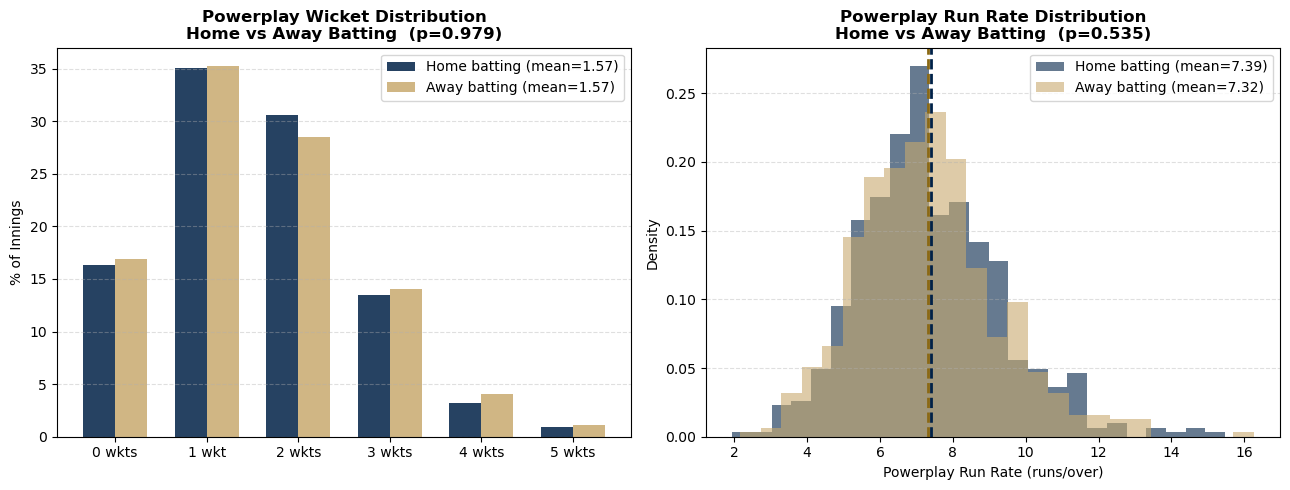

In [40]:
# Boxplots: home vs away first-six-over wickets and run rate.
import matplotlib.pyplot as plt
import numpy as np

NAVY = '#002147'
GOLD = '#C8A96E'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Wicket distribution (stacked bar) ---
ax1 = axes[0]
wicket_counts = range(0, 6)
home_pcts = [(home_pp['pp_wickets'] == w).mean() * 100 for w in wicket_counts]
away_pcts = [(away_pp['pp_wickets'] == w).mean() * 100 for w in wicket_counts]

x = np.arange(len(wicket_counts))
w = 0.35
ax1.bar(x - w/2, home_pcts, w, label=f'Home batting (mean={home_pp["pp_wickets"].mean():.2f})', color=NAVY, alpha=0.85)
ax1.bar(x + w/2, away_pcts, w, label=f'Away batting (mean={away_pp["pp_wickets"].mean():.2f})', color=GOLD, alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{w} wkt{"s" if w!=1 else ""}' for w in wicket_counts])
ax1.set_ylabel('% of Innings')
ax1.set_title(f'Powerplay Wicket Distribution\nHome vs Away Batting  (p={p_wkt:.3f})', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Plot 2: Run rate distribution ---
ax2 = axes[1]
ax2.hist(home_pp['pp_run_rate'], bins=25, alpha=0.6, color=NAVY,
         label=f'Home batting (mean={home_pp["pp_run_rate"].mean():.2f})', density=True)
ax2.hist(away_pp['pp_run_rate'], bins=25, alpha=0.6, color=GOLD,
         label=f'Away batting (mean={away_pp["pp_run_rate"].mean():.2f})', density=True)
ax2.axvline(home_pp['pp_run_rate'].mean(), color=NAVY, linestyle='--', linewidth=2)
ax2.axvline(away_pp['pp_run_rate'].mean(), color='#8B6914', linestyle='--', linewidth=2)
ax2.set_xlabel('Powerplay Run Rate (runs/over)')
ax2.set_ylabel('Density')
ax2.set_title(f'Powerplay Run Rate Distribution\nHome vs Away Batting  (p={p_rr:.3f})', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(DATA_DIR + "powerplay_home_vs_away.png", dpi=150)
plt.show()

### Step 5 — Key Findings

In [41]:
# Print Section 9 key findings: first-six-over performance.
print("=" * 60)
print("SECTION 9 KEY FINDINGS")
print("=" * 60)
print(f"\nPowerplay Wickets (overs 1-6):")
print(f"  Home batting : {home_pp['pp_wickets'].mean():.3f} wickets/innings")
print(f"  Away batting : {away_pp['pp_wickets'].mean():.3f} wickets/innings")
print(f"  Difference   : {away_pp['pp_wickets'].mean() - home_pp['pp_wickets'].mean():+.3f}")
print(f"  p-value      : {p_wkt:.4f} — {'SIGNIFICANT' if p_wkt < 0.05 else 'NOT significant'}")

print(f"\nPowerplay Run Rate (overs 1-6):")
print(f"  Home batting : {home_pp['pp_run_rate'].mean():.3f} runs/over")
print(f"  Away batting : {away_pp['pp_run_rate'].mean():.3f} runs/over")
print(f"  Difference   : {away_pp['pp_run_rate'].mean() - home_pp['pp_run_rate'].mean():+.3f}")
print(f"  p-value      : {p_rr:.4f} — {'SIGNIFICANT' if p_rr < 0.05 else 'NOT significant'}")

SECTION 9 KEY FINDINGS

Powerplay Wickets (overs 1-6):
  Home batting : 1.569 wickets/innings
  Away batting : 1.571 wickets/innings
  Difference   : +0.002
  p-value      : 0.9791 — NOT significant

Powerplay Run Rate (overs 1-6):
  Home batting : 7.389 runs/over
  Away batting : 7.317 runs/over
  Difference   : -0.072
  p-value      : 0.5350 — NOT significant


---
## Section 10: Bayesian Posterior Probability — DRS Umpiring Bias

The chi-square test in the DRS analysis ($p = 0.807$) is underpowered with only 156 reviews. A frequentist test can only say "we cannot reject the null" — it cannot quantify *how confident* we are that no bias exists.

A Bayesian approach answers a more natural question:

> **Given the observed review outcomes, what is the probability that home teams genuinely have a higher overturn rate than away teams?**

We model each team type's overturn rate as a Beta-Binomial:

$$\theta_{\text{home}} \sim \text{Beta}(1 + 25,\ 1 + 54) = \text{Beta}(26, 55)$$
$$\theta_{\text{away}} \sim \text{Beta}(1 + 22,\ 1 + 55) = \text{Beta}(23, 56)$$

**Prior:** Beta(1, 1) — uniform, expressing no prior belief about overturn rates before seeing the data.  
**Likelihood:** Binomial — 25 overturns from 79 home reviews; 22 from 77 away reviews.  
**Posterior:** Updated Beta distributions reflecting what the data tells us.

### Step 1 — Compute Posteriors

In [42]:
# Fit Beta posteriors for home and away DRS overturn probabilities.
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)
N = 1_000_000

# Verified data from drs_reviews.csv
home_upheld, home_total = 25, 79
away_upheld, away_total = 22, 77
home_struck = home_total - home_upheld  # 54
away_struck = away_total - away_upheld  # 55

# Beta posteriors: Beta(1 + successes, 1 + failures)
home_post = stats.beta(1 + home_upheld, 1 + home_struck)  # Beta(26, 55)
away_post = stats.beta(1 + away_upheld, 1 + away_struck)  # Beta(23, 56)

home_mean = home_post.mean()
away_mean = away_post.mean()
home_ci   = home_post.ppf([0.025, 0.975])
away_ci   = away_post.ppf([0.025, 0.975])

print("=" * 55)
print("BAYESIAN DRS ANALYSIS — POSTERIOR DISTRIBUTIONS")
print("=" * 55)
print(f"\nPrior: Beta(1, 1) — Uniform")
print(f"\nHome posterior : Beta(26, 55)")
print(f"  Mean                 : {home_mean:.4f}  ({home_mean*100:.2f}%)")
print(f"  95% Credible Interval: ({home_ci[0]:.4f}, {home_ci[1]:.4f})")
print(f"\nAway posterior : Beta(23, 56)")
print(f"  Mean                 : {away_mean:.4f}  ({away_mean*100:.2f}%)")
print(f"  95% Credible Interval: ({away_ci[0]:.4f}, {away_ci[1]:.4f})")

BAYESIAN DRS ANALYSIS — POSTERIOR DISTRIBUTIONS

Prior: Beta(1, 1) — Uniform

Home posterior : Beta(26, 55)
  Mean                 : 0.3210  (32.10%)
  95% Credible Interval: (0.2245, 0.4259)

Away posterior : Beta(23, 56)
  Mean                 : 0.2911  (29.11%)
  95% Credible Interval: (0.1970, 0.3953)


### Step 2 — Monte Carlo: P(θ_home > θ_away | data)

In [43]:
# Monte Carlo: draw 1M samples from each posterior to estimate P(home > away).
theta_home = home_post.rvs(N)
theta_away = away_post.rvs(N)

# Posterior of the difference
diff = theta_home - theta_away
diff_mean = diff.mean()
diff_ci   = np.percentile(diff, [2.5, 97.5])

# Key probabilities
prob_home_greater  = (theta_home > theta_away).mean()
prob_diff_gt_5pp   = (diff > 0.05).mean()
prob_diff_gt_10pp  = (diff > 0.10).mean()

print("=" * 55)
print("POSTERIOR OF DIFFERENCE (home - away overturn rate)")
print("=" * 55)
print(f"  Posterior mean       : {diff_mean:+.4f}  ({diff_mean*100:+.2f} pp)")
print(f"  95% Credible Interval: ({diff_ci[0]:+.4f}, {diff_ci[1]:+.4f})")
print()
print("=" * 55)
print("KEY POSTERIOR PROBABILITIES")
print("=" * 55)
print(f"  P(θ_home > θ_away | data)      = {prob_home_greater:.4f}  ({prob_home_greater*100:.1f}%)")
print(f"  P(difference > 5 pp | data)    = {prob_diff_gt_5pp:.4f}  ({prob_diff_gt_5pp*100:.1f}%)")
print(f"  P(difference > 10 pp | data)   = {prob_diff_gt_10pp:.4f}  ({prob_diff_gt_10pp*100:.1f}%)")
print()
print(f"  Monte Carlo samples: {N:,}")
print()
print("INTERPRETATION:")
print(f"  There is a {prob_home_greater*100:.1f}% posterior probability that home teams")
print(f"  have a higher DRS overturn rate than away teams.")
print(f"  There is a {(1-prob_home_greater)*100:.1f}% probability that away teams overturn at")
print(f"  the same rate or higher — consistent with no bias.")

POSTERIOR OF DIFFERENCE (home - away overturn rate)
  Posterior mean       : +0.0299  (+2.99 pp)
  95% Credible Interval: (-0.1122, +0.1712)

KEY POSTERIOR PROBABILITIES
  P(θ_home > θ_away | data)      = 0.6604  (66.0%)
  P(difference > 5 pp | data)    = 0.3912  (39.1%)
  P(difference > 10 pp | data)   = 0.1667  (16.7%)

  Monte Carlo samples: 1,000,000

INTERPRETATION:
  There is a 66.0% posterior probability that home teams
  have a higher DRS overturn rate than away teams.
  There is a 34.0% probability that away teams overturn at
  the same rate or higher — consistent with no bias.


### Step 3 — Visualise the Posteriors

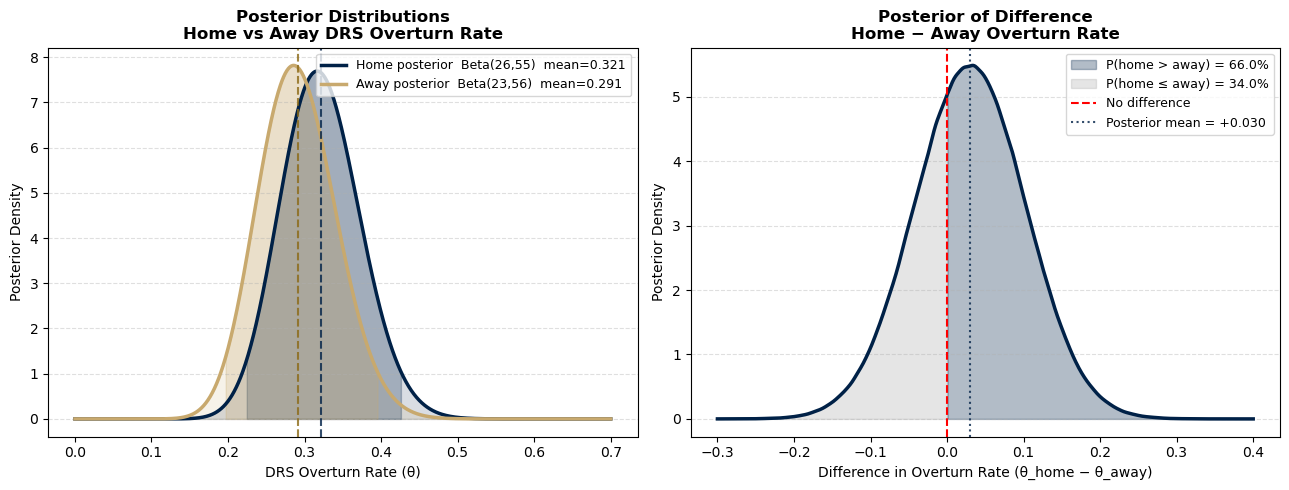

In [44]:
# Plot overlaid posteriors for home vs away DRS overturn rates.
NAVY = '#002147'
GOLD = '#C8A96E'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.linspace(0, 0.7, 1000)

# --- Plot 1: Posterior distributions ---
ax1 = axes[0]
ax1.plot(x, home_post.pdf(x), color=NAVY, linewidth=2.5,
         label=f'Home posterior  Beta(26,55)  mean={home_mean:.3f}')
ax1.plot(x, away_post.pdf(x), color=GOLD, linewidth=2.5,
         label=f'Away posterior  Beta(23,56)  mean={away_mean:.3f}')
ax1.fill_between(x, home_post.pdf(x), alpha=0.15, color=NAVY)
ax1.fill_between(x, away_post.pdf(x), alpha=0.15, color=GOLD)
ax1.axvline(home_mean, color=NAVY, linestyle='--', linewidth=1.5, alpha=0.8)
ax1.axvline(away_mean, color='#8B6914', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('DRS Overturn Rate (θ)')
ax1.set_ylabel('Posterior Density')
ax1.set_title('Posterior Distributions\nHome vs Away DRS Overturn Rate', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Add 95% CI shading
for post, ci, col in [(home_post, home_ci, NAVY), (away_post, away_ci, GOLD)]:
    x_ci = np.linspace(ci[0], ci[1], 500)
    ax1.fill_between(x_ci, post.pdf(x_ci), alpha=0.25, color=col)

# --- Plot 2: Posterior of the difference ---
ax2 = axes[1]
diff_x = np.linspace(-0.3, 0.4, 1000)
# KDE of the difference samples
from scipy.stats import gaussian_kde
kde = gaussian_kde(diff)
ax2.plot(diff_x, kde(diff_x), color=NAVY, linewidth=2.5)
ax2.fill_between(diff_x, kde(diff_x), where=(diff_x > 0), alpha=0.3, color=NAVY,
                 label=f'P(home > away) = {prob_home_greater*100:.1f}%')
ax2.fill_between(diff_x, kde(diff_x), where=(diff_x <= 0), alpha=0.2, color='grey',
                 label=f'P(home ≤ away) = {(1-prob_home_greater)*100:.1f}%')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No difference')
ax2.axvline(diff_mean, color=NAVY, linestyle=':', linewidth=1.5, alpha=0.8,
            label=f'Posterior mean = {diff_mean:+.3f}')
ax2.set_xlabel('Difference in Overturn Rate (θ_home − θ_away)')
ax2.set_ylabel('Posterior Density')
ax2.set_title('Posterior of Difference\nHome − Away Overturn Rate', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
DATA_DIR = "/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/"
plt.savefig(DATA_DIR + "drs_bayesian_posterior.png", dpi=150)
plt.show()

### Step 4 — Key Findings

In [45]:
# Print Bayesian DRS key findings and posterior probability.
print("=" * 60)
print("SECTION 10 KEY FINDINGS — BAYESIAN DRS ANALYSIS")
print("=" * 60)
print()
print("Observed data:")
print(f"  Home teams: {home_upheld} overturns from {home_total} reviews ({home_upheld/home_total*100:.1f}%)")
print(f"  Away teams: {away_upheld} overturns from {away_total} reviews ({away_upheld/away_total*100:.1f}%)")
print()
print("Posterior estimates:")
print(f"  Home true overturn rate: {home_mean:.4f}  95% CI: ({home_ci[0]:.3f}, {home_ci[1]:.3f})")
print(f"  Away true overturn rate: {away_mean:.4f}  95% CI: ({away_ci[0]:.3f}, {away_ci[1]:.3f})")
print()
print("Posterior probability of bias:")
print(f"  P(home overturn rate > away | data) = {prob_home_greater*100:.1f}%")
print()
print("Conclusion:")
print(f"  There is only a {prob_home_greater*100:.1f}% posterior probability that home")
print(f"  teams genuinely benefit from umpiring bias in DRS decisions.")
print(f"  The 95% credible interval for the difference ({diff_ci[0]:+.3f} to {diff_ci[1]:+.3f})")
print(f"  comfortably includes zero, confirming substantial uncertainty.")
print(f"  With only {home_total + away_total} total reviews, the data are insufficient")
print(f"  to detect a meaningful effect even if one exists.")

SECTION 10 KEY FINDINGS — BAYESIAN DRS ANALYSIS

Observed data:
  Home teams: 25 overturns from 79 reviews (31.6%)
  Away teams: 22 overturns from 77 reviews (28.6%)

Posterior estimates:
  Home true overturn rate: 0.3210  95% CI: (0.224, 0.426)
  Away true overturn rate: 0.2911  95% CI: (0.197, 0.395)

Posterior probability of bias:
  P(home overturn rate > away | data) = 66.0%

Conclusion:
  There is only a 66.0% posterior probability that home
  teams genuinely benefit from umpiring bias in DRS decisions.
  The 95% credible interval for the difference (-0.112 to +0.171)
  comfortably includes zero, confirming substantial uncertainty.
  With only 156 total reviews, the data are insufficient
  to detect a meaningful effect even if one exists.


### Step 5 — Sensitivity Check: Informative Prior Beta(3, 7)

A uniform prior assumes complete ignorance about DRS overturn rates. In practice, published ICC international match data shows overturn rates consistently near **30%**. We encode this as **Beta(3, 7)**: prior mean = 0.30, equivalent to 10 prior observations — expressing mild belief that data dominates quickly.

$$\theta_{\text{home}} \sim \text{Beta}(3 + 25,\ 7 + 54) = \text{Beta}(28, 61)$$
$$\theta_{\text{away}} \sim \text{Beta}(3 + 22,\ 7 + 55) = \text{Beta}(25, 62)$$

INFORMATIVE PRIOR: Beta(3, 7)  [mean=0.30, n_eff=10]
  Home posterior Beta(28,61): mean=0.3146  95% CI: (0.223, 0.414)
  Away posterior Beta(25,62): mean=0.2874  95% CI: (0.198, 0.386)
  Difference mean: +0.0274  95% CI: (-0.107, +0.162)
  P(θ_home > θ_away | data) = 0.6552  (65.5%)

PRIOR SENSITIVITY COMPARISON
  Prior                      Home mean  Away mean   P(home>away)
  ------------------------------------------------------------
  Uniform Beta(1,1)             32.10%     29.11%          66.0%
  Informative Beta(3,7)         31.46%     28.74%          65.5%

  The informative prior shrinks both posterior means slightly
  toward 30%, but the conclusion is robust: P(home > away)
  changes by only 0.5 percentage points across the two priors.


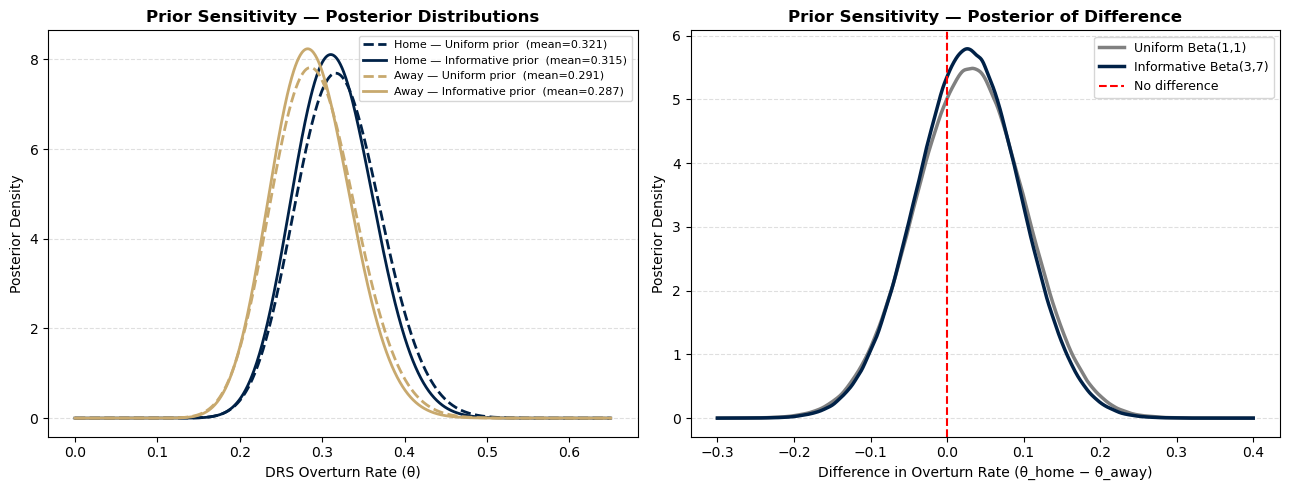

In [46]:
# Sensitivity check: re-run DRS analysis with informative Beta(3,7) prior.
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)
N = 1_000_000

home_upheld, home_total = 25, 79
away_upheld, away_total = 22, 77
home_struck = home_total - home_upheld
away_struck = away_total - away_upheld

# Informative prior: Beta(3, 7) — mean=0.30, strength=10
alpha_p, beta_p = 3, 7

home_post_inf = stats.beta(alpha_p + home_upheld, beta_p + home_struck)  # Beta(28, 61)
away_post_inf = stats.beta(alpha_p + away_upheld, beta_p + away_struck)  # Beta(25, 62)

# Uniform prior posteriors (for comparison)
home_post_unif = stats.beta(1 + home_upheld, 1 + home_struck)  # Beta(26, 55)
away_post_unif = stats.beta(1 + away_upheld, 1 + away_struck)  # Beta(23, 56)

# Monte Carlo — informative
th_home_inf = home_post_inf.rvs(N)
th_away_inf = away_post_inf.rvs(N)
diff_inf = th_home_inf - th_away_inf
prob_inf  = (th_home_inf > th_away_inf).mean()
diff_ci_inf = np.percentile(diff_inf, [2.5, 97.5])

print("=" * 58)
print("INFORMATIVE PRIOR: Beta(3, 7)  [mean=0.30, n_eff=10]")
print("=" * 58)
print(f"  Home posterior Beta(28,61): mean={home_post_inf.mean():.4f}  "
      f"95% CI: ({home_post_inf.ppf(0.025):.3f}, {home_post_inf.ppf(0.975):.3f})")
print(f"  Away posterior Beta(25,62): mean={away_post_inf.mean():.4f}  "
      f"95% CI: ({away_post_inf.ppf(0.025):.3f}, {away_post_inf.ppf(0.975):.3f})")
print(f"  Difference mean: {diff_inf.mean():+.4f}  95% CI: ({diff_ci_inf[0]:+.3f}, {diff_ci_inf[1]:+.3f})")
print(f"  P(θ_home > θ_away | data) = {prob_inf:.4f}  ({prob_inf*100:.1f}%)")

print()
print("=" * 58)
print("PRIOR SENSITIVITY COMPARISON")
print("=" * 58)
prob_unif = (home_post_unif.rvs(N) > away_post_unif.rvs(N)).mean()
print(f"  {'Prior':<25} {'Home mean':>10} {'Away mean':>10} {'P(home>away)':>14}")
print(f"  {'-'*60}")
print(f"  {'Uniform Beta(1,1)':<25} {home_post_unif.mean()*100:>9.2f}% {away_post_unif.mean()*100:>9.2f}% {prob_unif*100:>13.1f}%")
print(f"  {'Informative Beta(3,7)':<25} {home_post_inf.mean()*100:>9.2f}% {away_post_inf.mean()*100:>9.2f}% {prob_inf*100:>13.1f}%")
print()
print("  The informative prior shrinks both posterior means slightly")
print("  toward 30%, but the conclusion is robust: P(home > away)")
print(f"  changes by only {abs(prob_inf - prob_unif)*100:.1f} percentage points across the two priors.")

# Visualise both
NAVY, GOLD = '#002147', '#C8A96E'
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.linspace(0, 0.65, 1000)

ax1 = axes[0]
for post, label, col, ls in [
    (home_post_unif, 'Home — Uniform prior', NAVY, '--'),
    (home_post_inf,  'Home — Informative prior', NAVY, '-'),
    (away_post_unif, 'Away — Uniform prior', GOLD, '--'),
    (away_post_inf,  'Away — Informative prior', GOLD, '-'),
]:
    ax1.plot(x, post.pdf(x), color=col, linestyle=ls, linewidth=2,
             label=f'{label}  (mean={post.mean():.3f})')
ax1.set_xlabel('DRS Overturn Rate (θ)')
ax1.set_ylabel('Posterior Density')
ax1.set_title('Prior Sensitivity — Posterior Distributions', fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

from scipy.stats import gaussian_kde
ax2 = axes[1]
diff_x = np.linspace(-0.3, 0.4, 1000)
diff_unif = home_post_unif.rvs(N) - away_post_unif.rvs(N)
for d, label, col in [(diff_unif, 'Uniform Beta(1,1)', 'grey'),
                       (diff_inf,  'Informative Beta(3,7)', NAVY)]:
    kde = gaussian_kde(d)
    ax2.plot(diff_x, kde(diff_x), color=col, linewidth=2.5, label=label)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No difference')
ax2.set_xlabel('Difference in Overturn Rate (θ_home − θ_away)')
ax2.set_ylabel('Posterior Density')
ax2.set_title('Prior Sensitivity — Posterior of Difference', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
DATA_DIR = "/Users/osamagill/og_claude/DS Project B/Downloads/bbl_cleaned/"
plt.savefig(DATA_DIR + "drs_bayesian_sensitivity.png", dpi=150)
plt.show()